# estimating probability of kind-linked

In [32]:
import gp
import pickle as pkl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

## import zarpie features
each row is a feature. columns: category (personality, physical, diet), split (train or test), in_heterogenous (whether or not it was used for train / test in heterogenous condition), 2d embedding, 384d embedding.

In [33]:
with open('../features/set2_features_dataframe.pkl', 'rb') as f:
    df = pkl.load(f)

In [34]:
df.head()

,feature,category,split,in_heterogenous,x_2d,y_2d,embedding_384d
0,are angry,personality_behaviors,train,True,-0.073863,-0.238874,"[-0.02164809, 0.050021496, -0.027437702, 0.012..."
1,are brave,personality_behaviors,train,True,-0.100276,-0.269504,"[-0.022016477, -0.029494364, -0.042321444, 0.0..."
2,are curious,personality_behaviors,train,False,-0.085597,-0.184920,"[-0.06632441, 0.060695983, 0.0322907, 0.080090..."
3,are forgetful,personality_behaviors,train,False,-0.047072,-0.263889,"[-0.047100894, -0.008117868, -0.013956301, 0.0..."
4,are friendly,personality_behaviors,train,True,0.030569,-0.241963,"[-0.03688672, 0.047983356, -0.044930663, 0.021..."


In [35]:
phys_df = df[df['category'] == 'physical']
# phys_df

In [36]:
# 2d gp where the train features are 1 (kind-linked) and the test features are unknown / need to be predicted
# then other features possibly in the space should also be predicted

# Reload gp module to pick up changes
import importlib
importlib.reload(gp)

<module 'gp' from '/Users/mayamalaviya/Documents/PhD/GP Generics/compgenerics/model/gp/gp.py'>

In [37]:
# Extract training data (physical features in train split - these are kind-linked)
train_df = phys_df[phys_df['split'] == 'train']
train_coords = jnp.array(train_df[['x_2d', 'y_2d']].values)
train_labels = jnp.ones(len(train_coords))  # All training features are kind-linked (y=1)

# Extract test data (need to predict P(kind-linked))
test_df = phys_df[phys_df['split'] == 'test']
test_coords = jnp.array(test_df[['x_2d', 'y_2d']].values)

print(f"Training: {len(train_coords)} points")
print(f"Test: {len(test_coords)} points")

Training: 15 points
Test: 5 points


In [38]:
# Run Bernoulli GP classification
# prior_mean=0 means P(kind-linked) = .5
results = gp.bernoulli_gp_classify(
    train_coords=train_coords,
    train_labels=train_labels,
    test_coords=test_coords,
    kernel_name="rbf_2d_ard",
    prior_mean=0,
    return_latent=True
)

# Show results
print("Predicted P(kind-linked) for test features:")
print("-" * 50)
for feat, prob in zip(test_df['feature'].values, results['probabilities']):
    print(f"  {feat}: {float(prob):.3f}")

Predicted P(kind-linked) for test features:
--------------------------------------------------
  can roll their tongue: 0.688
  can snap with their toes: 0.706
  can wiggle their ears: 0.716
  have cold hands and feet: 0.713
  snore when they sleep: 0.668


## Predict on all features (not just physical)

We can also predict P(kind-linked) for features from other categories to see how the model generalizes.

In [39]:
# Predict on ALL features in the dataframe
all_coords = jnp.array(df[['x_2d', 'y_2d']].values)

# Get predictions for all features
all_probs, all_f_mean, all_f_var = gp.laplace_predict(
    X_train=train_coords,
    y_train=train_labels,
    X_test=all_coords,
    kernel_params=results['best_params'],
    kernel_name="rbf_2d_ard",
    prior_mean=0
)

In [40]:
# Add predictions to dataframe for analysis
df_with_preds = df.copy()
df_with_preds['p_kind_linked'] = np.array(all_probs)
df_with_preds['latent_mean'] = np.array(all_f_mean)
df_with_preds['latent_var'] = np.array(all_f_var)

# Show predictions by category
for cat in df['category'].unique():
    print(f"\n{cat.upper()}:")
    cat_df = df_with_preds[df_with_preds['category'] == cat].sort_values('p_kind_linked', ascending=False)
    for _, row in cat_df.iterrows():
        marker = "✓" if row['split'] == 'train' else "?"
        print(f"  {marker} {row['feature']}: {row['p_kind_linked']:.3f}")


PERSONALITY_BEHAVIORS:
  ✓ can do cartwheels: 0.709
  ? like to dance: 0.660
  ✓ live with their families: 0.657
  ? cry easily: 0.655
  ✓ like to ride bikes: 0.644
  ✓ are curious: 0.639
  ✓ tell bad jokes: 0.636
  ✓ teach children: 0.627
  ✓ are silly: 0.624
  ✓ are angry: 0.617
  ✓ are brave: 0.610
  ✓ are smart: 0.606
  ✓ take care of others: 0.606
  ✓ are forgetful: 0.604
  ? like to give high-fives: 0.597
  ✓ are friendly: 0.596
  ? like to read books: 0.595
  ? like to collect rocks: 0.586
  ✓ give good gifts: 0.585
  ✓ are thoughtful: 0.561

DIET_PREFERENCES:
  ✓ farm potatoes: 0.600
  ✓ make bread: 0.588
  ✓ really don't like ice cream: 0.586
  ✓ eat cheese: 0.581
  ✓ eat nuts: 0.579
  ✓ like to eat sweets: 0.572
  ✓ like to drink fizzy water: 0.566
  ✓ really don't like soup: 0.565
  ✓ drink milk: 0.564
  ? like juice with pulp: 0.562
  ? eat breakfast very late: 0.561
  ✓ eat meat: 0.561
  ✓ like to eat herbs: 0.558
  ✓ like to drink tea: 0.557
  ? can eat spicy food: 0.551

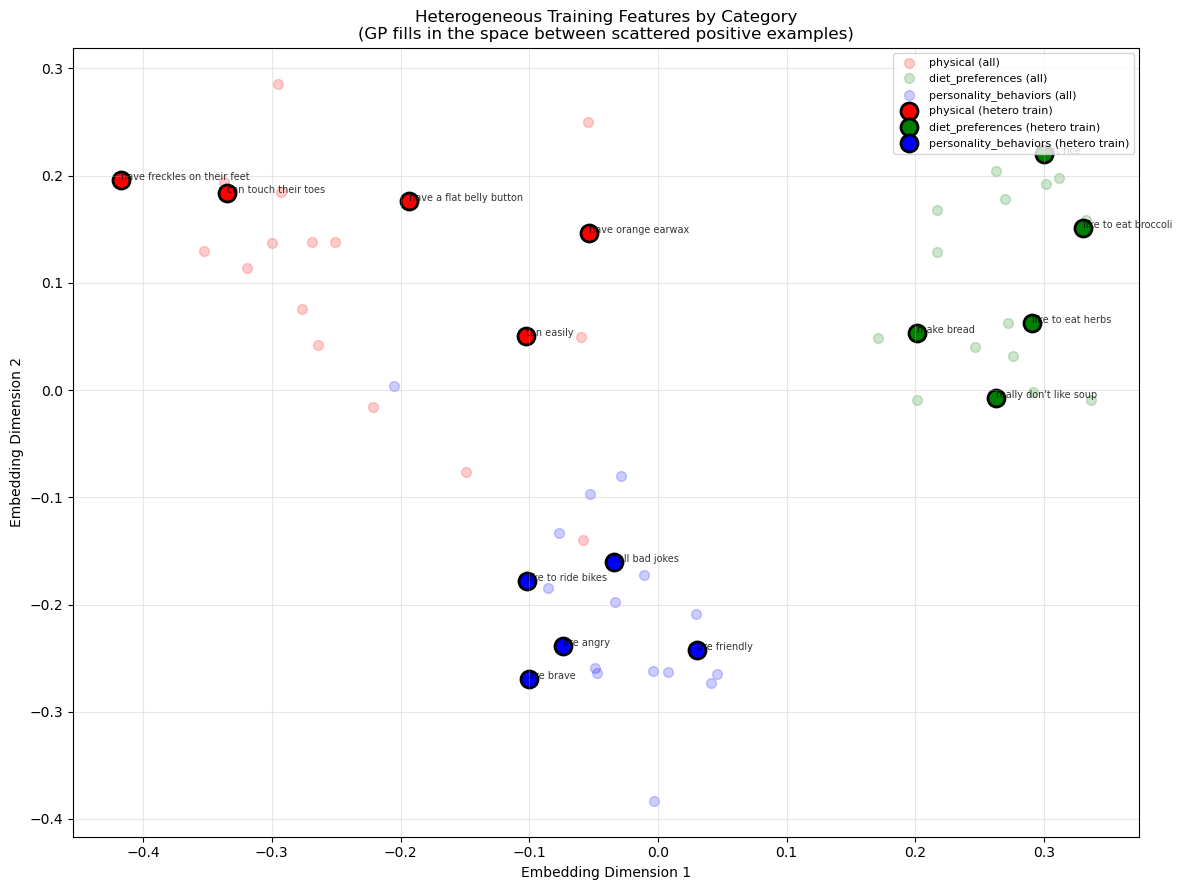


Heterogeneous training features by category:

physical: 5 features
  - can touch their toes
  - have a flat belly button
  - have freckles on their feet
  - have orange earwax
  - tan easily

diet_preferences: 5 features
  - eat rice
  - like to eat broccoli
  - like to eat herbs
  - make bread
  - really don't like soup

personality_behaviors: 5 features
  - are angry
  - are brave
  - are friendly
  - like to ride bikes
  - tell bad jokes


In [41]:
# Visualize WHERE the heterogeneous training points are by category
# This explains why there's a high-probability region in the middle

fig, ax = plt.subplots(figsize=(12, 9))

# Plot ALL features by category (faded)
colors = {'physical': 'red', 'diet_preferences': 'green', 'personality_behaviors': 'blue'}
for cat, color in colors.items():
    cat_df = df[df['category'] == cat]
    ax.scatter(cat_df['x_2d'], cat_df['y_2d'], 
               c=color, alpha=0.2, s=50, label=f'{cat} (all)')

# Highlight heterogeneous training features
hetero_train = df[(df['in_heterogenous'] == True) & (df['split'] == 'train')]
for cat, color in colors.items():
    cat_hetero = hetero_train[hetero_train['category'] == cat]
    ax.scatter(cat_hetero['x_2d'], cat_hetero['y_2d'], 
               c=color, s=150, edgecolors='black', linewidths=2,
               label=f'{cat} (hetero train)', marker='o')
    # Label them
    for _, row in cat_hetero.iterrows():
        ax.annotate(row['feature'], (row['x_2d'], row['y_2d']), 
                   fontsize=7, alpha=0.8)

ax.set_xlabel('Embedding Dimension 1')
ax.set_ylabel('Embedding Dimension 2')
ax.set_title('Heterogeneous Training Features by Category\n(GP fills in the space between scattered positive examples)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nHeterogeneous training features by category:")
for cat in colors.keys():
    cat_hetero = hetero_train[hetero_train['category'] == cat]
    print(f"\n{cat}: {len(cat_hetero)} features")
    for _, row in cat_hetero.iterrows():
        print(f"  - {row['feature']}")

## Per-participant GP model fitting

Fit a Bernoulli GP model to each participant's self-reported P(kind-linked) ratings (0–100 slider, normalized to [0,1]).
Training features are determined by the participant's condition (all labeled 1 = kind-linked).
We compare a **null model** (fixed large lengthscale ls=5.0, effectively flat predictions) against a
**fitted model** (isotropic lengthscale optimized per participant).

Likelihood: `responses_j ~ Normal(GP_prob_j(ls), sigma_noise=0.20)`.
Model comparison via log-likelihood difference and BIC (null has k=0 free params, fitted has k=1).

In [42]:
import importlib
importlib.reload(gp)
from scipy.stats import norm, pearsonr
import csv

# ── Constants ──────────────────────────────────────────────────────────────
GP_SIGMA    = 1.0    # fixed GP amplitude (not fit per participant)
PRIOR_MEAN  = 0      # P(kind-linked) = 0.5 far from training data
NULL_LS     = 5.0    # >> coordinate span (~0.75); gives effectively flat surface
SIGMA_NOISE = 0.20   # noise std for Normal likelihood (matches empirical within-ppt response std)
N_LS_GRID   = 500    # number of log-spaced lengthscale grid points
LOG_LS_MIN  = -5.0   # exp(-5) ≈ 0.007 (tighter than any training-point spacing)
LOG_LS_MAX  =  5.0   # exp(5)  ≈ 148   (extended upper bound; well beyond coordinate span)
N_PM_GRID   = 200    # number of prior_mean grid points (finer than previous 30)
PM_GRID_MIN = -4.0   # sigmoid(-4) ≈ 0.018 — very conservative rater (extended)
PM_GRID_MAX =  4.0   # sigmoid(+4) ≈ 0.982 — very generous rater (extended)

# ── CSV column → embedding feature name (verified mapping) ─────────────────
CSV_TO_FEATURE = {
    'diet_can_eat_spicy_1':   'can eat spicy food',
    'diet_breakfast_late_1':  'eat breakfast very late',
    'diet_five_meals_day_1':  'eat five meals a day',
    'diet_like_juice_pulp_1': 'like juice with pulp',
    'diet_pepper_on_all_1':   'put pepper on all their foods',
    'pers_cry_easily_1':      'cry easily',
    'pers_collect_rocks_1':   'like to collect rocks',
    'pers_like_to_dance_1':   'like to dance',
    'pers_like_highfive_1':   'like to give high-fives',
    'pers_read_books_1':      'like to read books',
    'phys_can_roll_tongue_1': 'can roll their tongue',
    'phys_can_snap_toes_1':   'can snap with their toes',
    'phys_can_wiggle_ears_1': 'can wiggle their ears',
    'phys_cold_hands_feet_1': 'have cold hands and feet',
    'phys_snore_sleep_1':     'snore when they sleep',
}
TEST_COLS = list(CSV_TO_FEATURE.keys())

print(f"Test features: {len(TEST_COLS)}, Null LS: {NULL_LS}, Sigma noise: {SIGMA_NOISE}")
print(f"LS grid: {N_LS_GRID} pts in [exp({LOG_LS_MIN:.1f})={np.exp(LOG_LS_MIN):.4f}, exp({LOG_LS_MAX:.1f})={np.exp(LOG_LS_MAX):.1f}]")
print(f"PM grid: {N_PM_GRID} pts in [{PM_GRID_MIN}, {PM_GRID_MAX}]  (spacing={( PM_GRID_MAX - PM_GRID_MIN)/(N_PM_GRID-1):.3f})")

Test features: 15, Null LS: 5.0, Sigma noise: 0.2
LS grid: 500 pts in [exp(-5.0)=0.0067, exp(5.0)=148.4]
PM grid: 200 pts in [-4.0, 4.0]  (spacing=0.040)


In [43]:
# ── Load participant data ──────────────────────────────────────────────────
# study9.csv has 3 header rows (col names, Qualtrics labels, importIds); data starts at row 3
with open('../../data/study9.csv') as f:
    rows = list(csv.reader(f))

CSV_HEADER = rows[0]
data_rows  = rows[3:]

cond_idx = CSV_HEADER.index('condition')

participants = []
for row in data_rows:
    cond      = row[cond_idx]
    responses = np.array([float(row[CSV_HEADER.index(c)]) / 100.0 for c in TEST_COLS])
    participants.append({'condition': cond, 'responses': responses})

# ── Summary ────────────────────────────────────────────────────────────────
from collections import Counter
cond_counts = Counter(p['condition'] for p in participants)
print(f"Total participants: {len(participants)}")
for cond, n in sorted(cond_counts.items()):
    print(f"  {cond}: n={n}")
all_resp = np.concatenate([p['responses'] for p in participants])
print(f"\nResponse range: [{all_resp.min():.3f}, {all_resp.max():.3f}]")
print(f"Mean within-participant std: {np.mean([np.std(p['responses']) for p in participants]):.3f}")

Total participants: 402
  diet: n=101
  heterogeneous: n=99
  personality: n=101
  physical: n=101

Response range: [0.000, 1.000]
Mean within-participant std: 0.201


In [44]:
# ── Test feature 2D coordinates (in CSV_TO_FEATURE column order) ──────────
feat_idx  = df.set_index('feature')
X_test = jnp.array([
    feat_idx.loc[CSV_TO_FEATURE[c], ['x_2d', 'y_2d']].values
    for c in TEST_COLS
])
print(f"X_test shape: {X_test.shape}")  # (15, 2)

# ── Training features per condition ───────────────────────────────────────
def get_condition_train(condition):
    """Return (X_train, y_train) for the given experimental condition."""
    if condition == 'physical':
        mask = (df['category'] == 'physical') & (df['split'] == 'train')
    elif condition == 'diet':
        mask = (df['category'] == 'diet_preferences') & (df['split'] == 'train')
    elif condition == 'personality':
        mask = (df['category'] == 'personality_behaviors') & (df['split'] == 'train')
    elif condition == 'heterogeneous':
        mask = (df['in_heterogenous'] == True) & (df['split'] == 'train')
    else:
        raise ValueError(f"Unknown condition: {condition!r}")
    train_df = df[mask]
    X = jnp.array(train_df[['x_2d', 'y_2d']].values)
    y = jnp.ones(len(X))
    return X, y

for cond in ['physical', 'diet', 'personality', 'heterogeneous']:
    X_tr, y_tr = get_condition_train(cond)
    print(f"  {cond}: {len(X_tr)} training features")

X_test shape: (15, 2)
  physical: 15 training features
  diet: 15 training features
  personality: 15 training features
  heterogeneous: 15 training features


In [45]:
# ── Precompute GP prediction grids ────────────────────────────────────────
# Instead of running scipy per participant (~590s), we precompute predictions at
# 500 log-spaced lengthscales for each condition using laplace_predict_batch (~2s total).
# Per-participant fitting is then a fast numpy argmax over this precomputed grid.

ls_grid = np.exp(np.linspace(LOG_LS_MIN, LOG_LS_MAX, N_LS_GRID))
kp_grid = jnp.array([[GP_SIGMA, ls, ls] for ls in ls_grid])   # (N_LS_GRID, 3) isotropic
null_kp = jnp.array([GP_SIGMA, NULL_LS, NULL_LS])

condition_grids = {}   # cond -> (N_LS_GRID, 15) GP probabilities  [fitted-ls model]
condition_null  = {}   # cond -> (15,) GP probabilities at NULL_LS  [null model]

for cond in ['physical', 'diet', 'personality', 'heterogeneous']:
    X_tr, y_tr = get_condition_train(cond)

    # Grid predictions (prior_mean=0 fixed for fitted-ls model)
    batch_probs, _, _ = gp.laplace_predict_batch(
        X_tr, y_tr, X_test, kp_grid,
        kernel_name='rbf_2d_ard', prior_mean=PRIOR_MEAN
    )
    condition_grids[cond] = np.array(batch_probs)   # (N_LS_GRID, 15)

    # Null model predictions (single call at large ls)
    null_probs, _, _ = gp.laplace_predict(
        X_tr, y_tr, X_test, null_kp,
        kernel_name='rbf_2d_ard', prior_mean=PRIOR_MEAN
    )
    condition_null[cond] = np.array(null_probs)      # (15,)

    null = condition_null[cond]
    grid = condition_grids[cond]
    print(f"{cond}: 1D grid shape={grid.shape}, "
          f"null probs range=[{null.min():.3f}, {null.max():.3f}]")

print("\n1D grid precomputation complete.")

# ── 1D pm grid: (N_PM_GRID, 15) per condition — fitted-pm model ───────────
# Fixes ls=NULL_LS, sweeps prior_mean only.  Fast: 4 × 1 laplace_predict call each.

pm_grid = np.linspace(PM_GRID_MIN, PM_GRID_MAX, N_PM_GRID)

N_TEST = len(TEST_COLS)   # 15

condition_grids_pm = {}   # cond -> (N_PM_GRID, 15)

for cond in ['physical', 'diet', 'personality', 'heterogeneous']:
    X_tr, y_tr = get_condition_train(cond)
    grids_pm = np.zeros((N_PM_GRID, N_TEST), dtype=np.float32)
    for j, pm in enumerate(pm_grid):
        probs_pm, _, _ = gp.laplace_predict(
            X_tr, y_tr, X_test, null_kp,
            kernel_name='rbf_2d_ard', prior_mean=float(pm)
        )
        grids_pm[j] = np.array(probs_pm, dtype=np.float32)
    condition_grids_pm[cond] = grids_pm
    print(f"{cond}: pm-only grid shape={grids_pm.shape}")

print("\npm-only grid precomputation complete.")

# ── 2D grid: (N_LS_GRID, N_PM_GRID, 15) per condition ─────────────────────
# Sweeps over both lengthscale AND prior_mean for the fitted-both model.
# Runtime: 4 conditions × 30 pm values × 1 laplace_predict_batch call ≈ 60s

condition_grids_2d = {}   # cond -> (N_LS_GRID, N_PM_GRID, 15)

for cond in ['physical', 'diet', 'personality', 'heterogeneous']:
    X_tr, y_tr = get_condition_train(cond)
    grids_2d = np.zeros((N_LS_GRID, N_PM_GRID, N_TEST), dtype=np.float32)
    for j, pm in enumerate(pm_grid):
        probs_pm, _, _ = gp.laplace_predict_batch(
            X_tr, y_tr, X_test, kp_grid,
            kernel_name='rbf_2d_ard', prior_mean=float(pm)
        )
        grids_2d[:, j, :] = np.array(probs_pm, dtype=np.float32)   # (N_LS_GRID, 15)
    condition_grids_2d[cond] = grids_2d
    print(f"{cond}: 2D grid shape={grids_2d.shape}")

print("\n2D grid precomputation complete.")


physical: 1D grid shape=(500, 15), null probs range=[0.855, 0.857]
diet: 1D grid shape=(500, 15), null probs range=[0.855, 0.857]
personality: 1D grid shape=(500, 15), null probs range=[0.856, 0.857]
heterogeneous: 1D grid shape=(500, 15), null probs range=[0.856, 0.857]

1D grid precomputation complete.
physical: pm-only grid shape=(200, 15)
diet: pm-only grid shape=(200, 15)
personality: pm-only grid shape=(200, 15)
heterogeneous: pm-only grid shape=(200, 15)

pm-only grid precomputation complete.
physical: 2D grid shape=(500, 200, 15)
diet: 2D grid shape=(500, 200, 15)
personality: 2D grid shape=(500, 200, 15)
heterogeneous: 2D grid shape=(500, 200, 15)

2D grid precomputation complete.


In [46]:
# ── Per-participant model fitting ─────────────────────────────────────────
# Four models, all using Normal likelihood: responses_j ~ Normal(GP_prob_j, sigma_noise)
#
#   Null        (k=0): ls=NULL_LS, prior_mean=0  (both fixed)
#   Fitted-pm   (k=1): ls=NULL_LS fixed, prior_mean optimized
#   Fitted-ls   (k=1): ls optimized, prior_mean=0 fixed
#   Fitted-both (k=2): ls + prior_mean both optimized
#
# BIC = -2 * log_lik + k * log(n),  n=15 test features

results = []
for p in participants:
    cond      = p['condition']
    responses = p['responses']   # (15,) in [0, 1]

    # ── Null model (k=0) ──────────────────────────────────────────────────
    null_preds = condition_null[cond]   # (15,)
    null_ll    = float(np.sum(norm.logpdf(responses, loc=null_preds, scale=SIGMA_NOISE)))
    bic_null   = -2 * null_ll           # k=0

    # ── Fitted-pm model (k=1): ls=NULL_LS fixed, prior_mean fit ───────────
    grid_pm  = condition_grids_pm[cond]   # (N_PM_GRID, 15)
    lls_pm   = np.sum(norm.logpdf(responses[None, :], loc=grid_pm, scale=SIGMA_NOISE), axis=1)
    best_pm_idx_1d   = int(np.argmax(lls_pm))
    fitted_pm_pm     = float(pm_grid[best_pm_idx_1d])
    fitted_pm_ll     = float(lls_pm[best_pm_idx_1d])
    fitted_pm_preds  = np.array(grid_pm[best_pm_idx_1d])   # (15,)
    bic_fitted_pm    = -2 * fitted_pm_ll + 1 * np.log(N_TEST)   # k=1

    # ── Fitted-ls model (k=1) ─────────────────────────────────────────────
    grid     = condition_grids[cond]   # (N_LS_GRID, 15)
    lls      = np.sum(norm.logpdf(responses[None, :], loc=grid, scale=SIGMA_NOISE), axis=1)
    best_idx = int(np.argmax(lls))
    fitted_ls    = float(ls_grid[best_idx])
    fitted_ll    = float(lls[best_idx])
    fitted_preds = grid[best_idx]      # (15,)
    bic_fitted   = -2 * fitted_ll + 1 * np.log(N_TEST)   # k=1

    # ── Fitted-both model (k=2) ───────────────────────────────────────────
    grid_2d  = condition_grids_2d[cond]   # (N_LS_GRID, N_PM_GRID, 15)
    lls_2d   = np.sum(
        norm.logpdf(responses[None, None, :], loc=grid_2d, scale=SIGMA_NOISE),
        axis=2
    )
    best_ls_idx, best_pm_idx = np.unravel_index(np.argmax(lls_2d), lls_2d.shape)
    fitted_both_ls    = float(ls_grid[best_ls_idx])
    fitted_both_pm    = float(pm_grid[best_pm_idx])
    fitted_both_ll    = float(lls_2d[best_ls_idx, best_pm_idx])
    fitted_both_preds = np.array(grid_2d[best_ls_idx, best_pm_idx])   # (15,)
    bic_both          = -2 * fitted_both_ll + 2 * np.log(N_TEST)      # k=2

    # ── Correlations ──────────────────────────────────────────────────────
    def safe_r(preds):
        if np.std(preds) > 1e-6 and np.std(responses) > 1e-6:
            return float(pearsonr(preds, responses)[0])
        return np.nan

    results.append({
        'condition':     cond,
        'responses':     responses,
        # Null
        'null_ll':       null_ll,
        'bic_null':      bic_null,
        'null_preds':    null_preds,
        # Fitted-pm
        'fitted_pm_pm':    fitted_pm_pm,
        'fitted_pm_ll':    fitted_pm_ll,
        'fitted_pm_preds': fitted_pm_preds,
        'bic_fitted_pm':   bic_fitted_pm,
        'delta_ll_pm':     fitted_pm_ll - null_ll,
        'delta_bic_pm':    bic_null - bic_fitted_pm,
        'r_pm':            safe_r(fitted_pm_preds),
        # Fitted-ls
        'fitted_ls':     fitted_ls,
        'fitted_ll':     fitted_ll,
        'fitted_preds':  fitted_preds,
        'bic_fitted':    bic_fitted,
        'delta_ll':      fitted_ll - null_ll,
        'delta_bic':     bic_null - bic_fitted,
        'r_fitted':      safe_r(fitted_preds),
        # Fitted-both
        'fitted_both_ls':    fitted_both_ls,
        'fitted_both_pm':    fitted_both_pm,
        'fitted_both_ll':    fitted_both_ll,
        'fitted_both_preds': fitted_both_preds,
        'bic_both':          bic_both,
        'delta_ll_both':     fitted_both_ll - null_ll,
        'delta_bic_both_vs_null':   bic_null      - bic_both,
        'delta_bic_both_vs_fitted': bic_fitted    - bic_both,
        'delta_bic_both_vs_pm':     bic_fitted_pm - bic_both,
        'r_both':            safe_r(fitted_both_preds),
    })

n_pm_wins  = sum(r['delta_ll_pm'] > 0 for r in results)
n_ls_wins  = sum(r['delta_ll']    > 0 for r in results)
n_both_wins= sum(r['delta_ll_both'] > 0 for r in results)
n_bic_pm   = sum(r['delta_bic_pm'] > 0 for r in results)
n_bic_ls   = sum(r['delta_bic']   > 0 for r in results)
print(f"Fitted {len(results)} participants.")
print(f"Fitted-pm   wins (Δll > 0):        {n_pm_wins}  / {len(results)}")
print(f"Fitted-ls   wins (Δll > 0):        {n_ls_wins}  / {len(results)}")
print(f"Fitted-both wins (Δll > 0):        {n_both_wins} / {len(results)}")
print(f"Fitted-pm   wins BIC vs null:      {n_bic_pm} / {len(results)}")
print(f"Fitted-ls   wins BIC vs null:      {n_bic_ls} / {len(results)}")


Fitted 402 participants.
Fitted-pm   wins (Δll > 0):        402  / 402
Fitted-ls   wins (Δll > 0):        402  / 402
Fitted-both wins (Δll > 0):        402 / 402
Fitted-pm   wins BIC vs null:      372 / 402
Fitted-ls   wins BIC vs null:      342 / 402


Condition           n   mean LLR   med LLR   % p<.05   % FDR<.05   agg LLR       agg p
--------------------------------------------------------------------------------
physical          101     18.273     8.457     66.3%       62.4%   1845.59      0.0000
diet              101     25.342    20.130     76.2%       75.2%   2559.52      0.0000
personality       101     23.065    19.121     74.3%       73.3%   2329.51      0.0000
heterogeneous      99     25.149    15.002     71.7%       69.7%   2489.76      0.0000
--------------------------------------------------------------------------------
ALL               402     22.946    16.123     72.1%       70.1%   9224.39           0

Aggregate LLR (sum over all 402 participants): 9224.39, chi²(df=402), p = 0


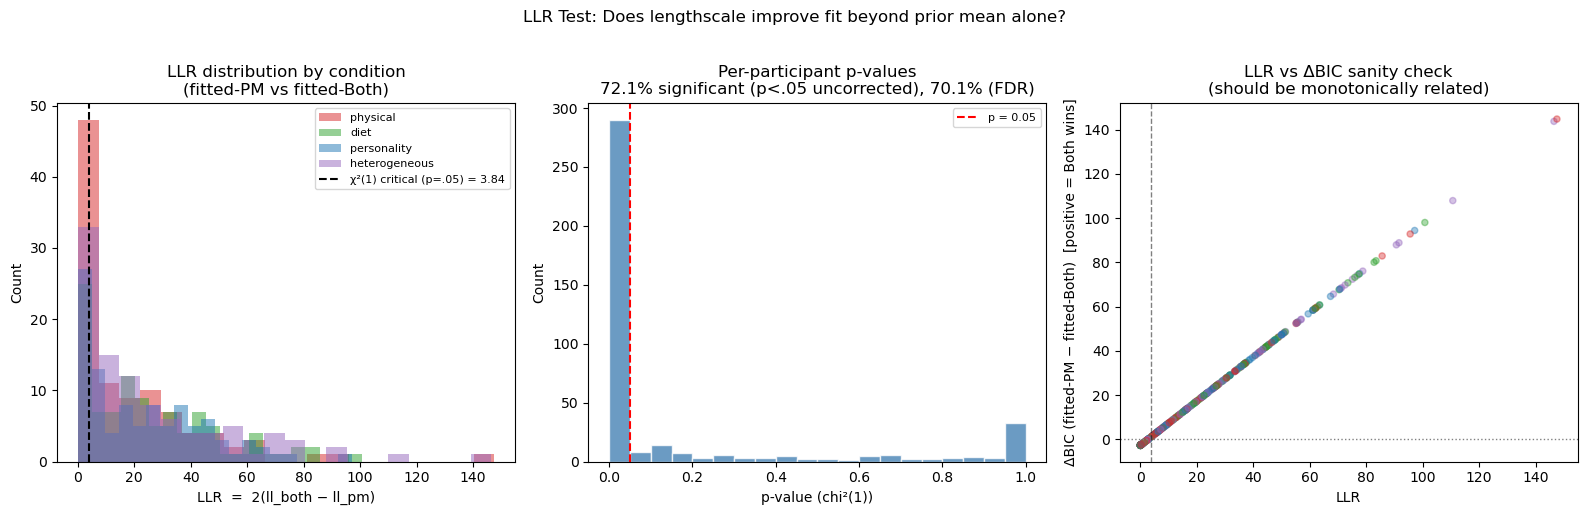

In [49]:
# ── Log-Likelihood Ratio Test: Fitted-PM (mean only) vs Fitted-Both (mean + LS) ──
# Nested models: Fitted-PM (k=1) ⊂ Fitted-Both (k=2)
# H0: lengthscale adds nothing (true model is Fitted-PM)
# Test statistic: LLR = 2 * (ll_both - ll_pm) ~ chi²(df=1) under H0

from scipy.stats import chi2
from statsmodels.stats.multitest import multipletests

N = len(results)

llr        = np.array([2 * (r['fitted_both_ll'] - r['fitted_pm_ll']) for r in results])
pvals      = chi2.sf(llr, df=1)
conditions = np.array([r['condition'] for r in results])

# FDR correction (Benjamini-Hochberg) across participants
_, pvals_fdr, _, _ = multipletests(pvals, method='fdr_bh')

for r, lv, pv, pv_fdr in zip(results, llr, pvals, pvals_fdr):
    r['llr_pm_vs_both']     = float(lv)
    r['llr_pval']           = float(pv)
    r['llr_pval_fdr']       = float(pv_fdr)
    r['llr_sig']            = pv     < 0.05
    r['llr_sig_fdr']        = pv_fdr < 0.05

# ── Per-condition summary ─────────────────────────────────────────────────
print(f"{'Condition':<16} {'n':>4}  {'mean LLR':>9}  {'med LLR':>8}  "
      f"{'% p<.05':>8}  {'% FDR<.05':>10}  {'agg LLR':>8}  {'agg p':>10}")
print('-' * 80)
for cond in ['physical', 'diet', 'personality', 'heterogeneous']:
    idx = conditions == cond
    lv  = llr[idx];  pv = pvals[idx];  pv_f = pvals_fdr[idx]
    agg_llr = lv.sum()
    agg_p   = chi2.sf(agg_llr, df=idx.sum())   # aggregate test: sum LLR ~ chi²(N_cond)
    print(f"{cond:<16} {idx.sum():>4}  {lv.mean():>9.3f}  {np.median(lv):>8.3f}  "
          f"{100*np.mean(pv < 0.05):>7.1f}%  {100*np.mean(pv_f < 0.05):>9.1f}%  "
          f"{agg_llr:>8.2f}  {agg_p:>10.4f}")

# ── Overall aggregate test ────────────────────────────────────────────────
agg_llr_all = llr.sum()
agg_p_all   = chi2.sf(agg_llr_all, df=N)
print('-' * 80)
print(f"{'ALL':<16} {N:>4}  {llr.mean():>9.3f}  {np.median(llr):>8.3f}  "
      f"{100*np.mean(pvals < 0.05):>7.1f}%  {100*np.mean(pvals_fdr < 0.05):>9.1f}%  "
      f"{agg_llr_all:>8.2f}  {agg_p_all:>10.4g}")
print(f"\nAggregate LLR (sum over all {N} participants): {agg_llr_all:.2f}, "
      f"chi²(df={N}), p = {agg_p_all:.4g}")

# ── Visualization ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Distribution of LLR values by condition
ax = axes[0]
cond_colors = {'physical': 'tab:red', 'diet': 'tab:green',
               'personality': 'tab:blue', 'heterogeneous': 'tab:purple'}
for cond in ['physical', 'diet', 'personality', 'heterogeneous']:
    idx = conditions == cond
    ax.hist(llr[idx], bins=20, alpha=0.5, label=cond, color=cond_colors[cond])
ax.axvline(chi2.ppf(0.95, df=1), color='black', linestyle='--', linewidth=1.5,
           label=f'χ²(1) critical (p=.05) = {chi2.ppf(0.95, df=1):.2f}')
ax.set_xlabel('LLR  =  2(ll_both − ll_pm)')
ax.set_ylabel('Count')
ax.set_title('LLR distribution by condition\n(fitted-PM vs fitted-Both)')
ax.legend(fontsize=8)

# Panel 2: p-value distribution
ax = axes[1]
ax.hist(pvals, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0.05, color='red', linestyle='--', linewidth=1.5, label='p = 0.05')
ax.set_xlabel('p-value (chi²(1))')
ax.set_ylabel('Count')
ax.set_title(f'Per-participant p-values\n'
             f'{np.mean(pvals < 0.05)*100:.1f}% significant (p<.05 uncorrected), '
             f'{np.mean(pvals_fdr < 0.05)*100:.1f}% (FDR)')
ax.legend(fontsize=8)

# Panel 3: LLR vs delta-BIC sanity check
ax = axes[2]
delta_bic_pm_vs_both = np.array([r['delta_bic_both_vs_pm'] for r in results])
ax.scatter(llr, delta_bic_pm_vs_both, alpha=0.4, s=20,
           c=[cond_colors[r['condition']] for r in results])
ax.axhline(0, color='gray', linestyle=':', linewidth=1)
ax.axvline(chi2.ppf(0.95, df=1), color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('LLR')
ax.set_ylabel('ΔBIC (fitted-PM − fitted-Both)  [positive = Both wins]')
ax.set_title('LLR vs ΔBIC sanity check\n(should be monotonically related)')

plt.suptitle('LLR Test: Does lengthscale improve fit beyond prior mean alone?',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [50]:
# ── Summary table by condition (4-model comparison) ───────────────────────
summary = []
for cond in ['physical', 'diet', 'personality', 'heterogeneous']:
    cr  = [r for r in results if r['condition'] == cond]
    rs  = [r['r_fitted'] for r in cr if not np.isnan(r['r_fitted'])]
    rp  = [r['r_pm']     for r in cr if not np.isnan(r['r_pm'])]
    rb  = [r['r_both']   for r in cr if not np.isnan(r['r_both'])]
    summary.append({
        'condition':                     cond,
        'n':                             len(cr),
        # Fitted-pm (k=1)
        'median_pm':                     np.median([r['fitted_pm_pm'] for r in cr]),
        'mean_delta_ll_pm':              np.mean([r['delta_ll_pm']   for r in cr]),
        'pct_pm_beats_null_bic':         100 * np.mean([r['delta_bic_pm']  > 0 for r in cr]),
        'mean_r_pm':                     np.mean(rp) if rp else np.nan,
        # Fitted-ls (k=1)
        'median_ls':                     np.median([r['fitted_ls']  for r in cr]),
        'mean_delta_ll':                 np.mean([r['delta_ll']     for r in cr]),
        'pct_ls_beats_null_bic':         100 * np.mean([r['delta_bic']    > 0 for r in cr]),
        'mean_r_fitted':                 np.mean(rs) if rs else np.nan,
        # Fitted-both (k=2)
        'median_both_ls':                np.median([r['fitted_both_ls'] for r in cr]),
        'median_both_pm':                np.median([r['fitted_both_pm'] for r in cr]),
        'mean_delta_ll_both':            np.mean([r['delta_ll_both']   for r in cr]),
        'mean_delta_bic_both_vs_null':   np.mean([r['delta_bic_both_vs_null']   for r in cr]),
        'mean_delta_bic_both_vs_fitted': np.mean([r['delta_bic_both_vs_fitted'] for r in cr]),
        'mean_delta_bic_both_vs_pm':     np.mean([r['delta_bic_both_vs_pm']     for r in cr]),
        'pct_both_beats_ls_bic':         100 * np.mean([r['delta_bic_both_vs_fitted'] > 0 for r in cr]),
        'pct_both_beats_pm_bic':         100 * np.mean([r['delta_bic_both_vs_pm']     > 0 for r in cr]),
        'mean_r_both':                   np.mean(rb) if rb else np.nan,
    })

summary_df = pd.DataFrame(summary)
summary_df


,condition,n,median_pm,mean_delta_ll_pm,pct_pm_beats_null_bic,mean_r_pm,median_ls,mean_delta_ll,pct_ls_beats_null_bic,mean_r_fitted,median_both_ls,median_both_pm,mean_delta_ll_both,mean_delta_bic_both_vs_null,mean_delta_bic_both_vs_fitted,mean_delta_bic_both_vs_pm,pct_both_beats_ls_bic,pct_both_beats_pm_bic,mean_r_both
0,physical,101,-3.316583,12.777846,96.039604,0.047634,0.037758,19.396919,84.158416,0.011665,0.016603,-0.422111,21.914444,38.412787,2.326999,15.565145,53.465347,66.336634,0.042202
1,diet,101,-3.316583,15.477709,90.099010,0.143218,0.010683,25.382396,82.178218,0.057175,0.023342,-0.462312,28.148611,50.881122,2.824381,22.633755,54.455446,79.207921,0.146726
2,personality,101,-3.316583,13.686941,89.108911,0.329708,0.048023,22.582559,86.138614,0.227854,0.066176,-0.703518,25.219191,45.022282,2.565215,20.356450,48.514851,79.207921,0.348239
3,heterogeneous,99,-3.316583,14.654330,94.949495,0.157557,0.006738,23.723564,87.878788,-0.012173,0.163062,-2.070352,27.228854,49.041607,4.302530,22.440996,53.535354,71.717172,0.323254


/var/folders/qb/4f5th4w557qd4b1rmp7v8lxm0000gq/T/ipykernel_70615/740941676.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cond, labels=cond_order, patch_artist=True)


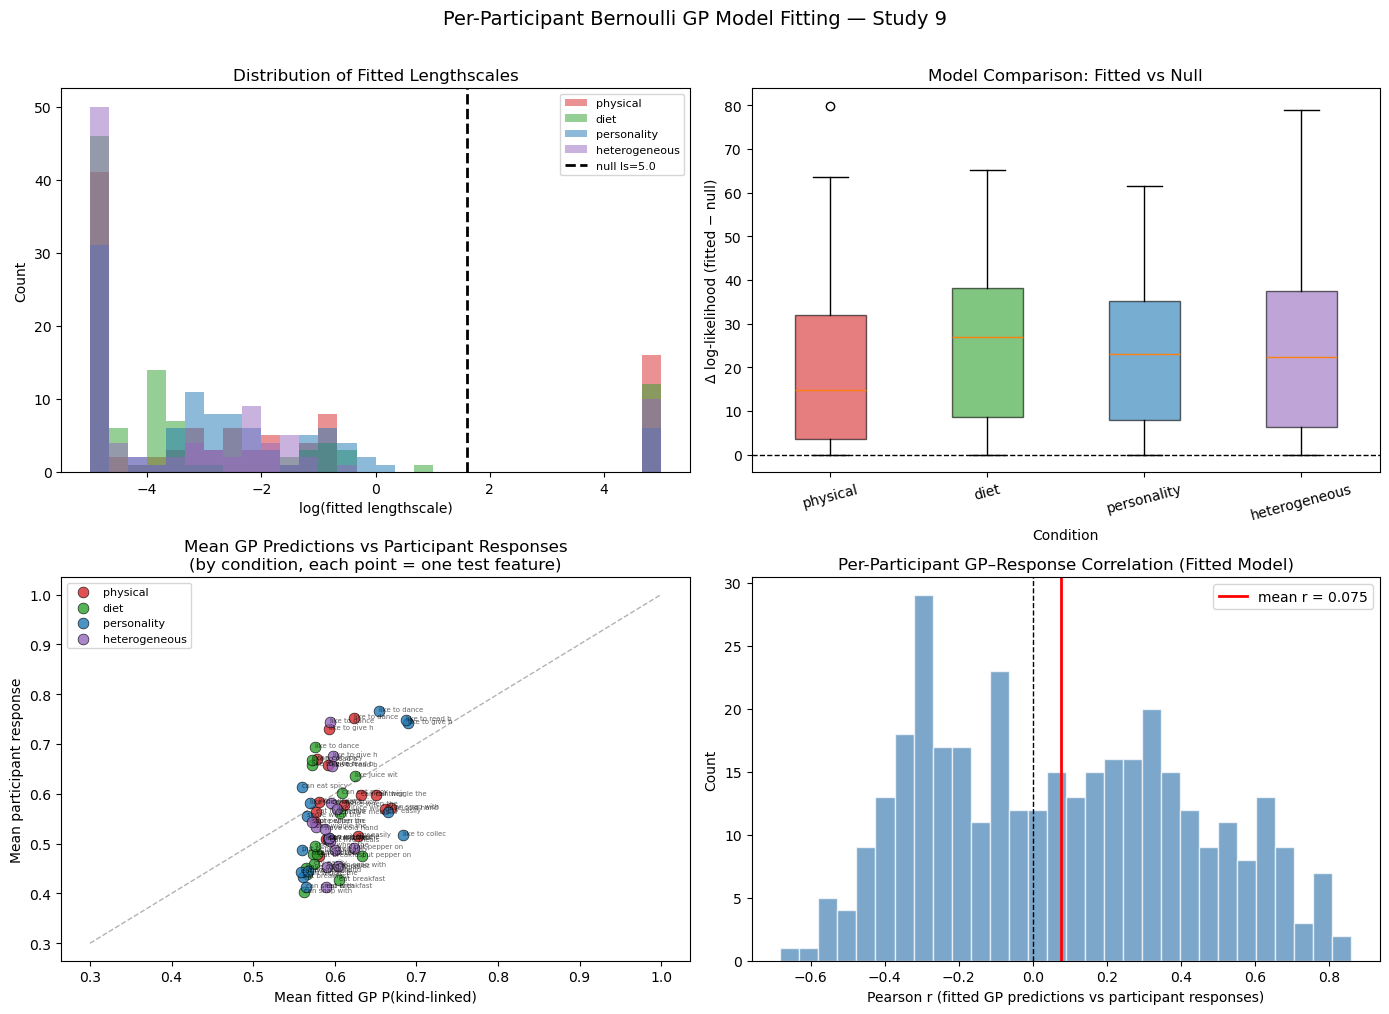

In [51]:
# ── 4-panel results visualization ─────────────────────────────────────────
cond_colors = {
    'physical':    'tab:red',
    'diet':        'tab:green',
    'personality': 'tab:blue',
    'heterogeneous': 'tab:purple',
}
cond_order = ['physical', 'diet', 'personality', 'heterogeneous']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Panel 1: Distribution of fitted lengthscales ──────────────────────────
ax = axes[0, 0]
for cond in cond_order:
    ls_vals = [r['fitted_ls'] for r in results if r['condition'] == cond]
    ax.hist(np.log(ls_vals), bins=30, alpha=0.5, label=cond, color=cond_colors[cond])
ax.axvline(x=np.log(NULL_LS), color='black', linestyle='--', linewidth=2,
           label=f'null ls={NULL_LS}')
ax.set_xlabel('log(fitted lengthscale)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Fitted Lengthscales')
ax.legend(fontsize=8)

# ── Panel 2: Delta log-likelihood (fitted − null) ─────────────────────────
ax = axes[0, 1]
data_by_cond = [[r['delta_ll'] for r in results if r['condition'] == c]
                for c in cond_order]
bp = ax.boxplot(data_by_cond, labels=cond_order, patch_artist=True)
for patch, cond in zip(bp['boxes'], cond_order):
    patch.set_facecolor(cond_colors[cond])
    patch.set_alpha(0.6)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Condition')
ax.set_ylabel('Δ log-likelihood (fitted − null)')
ax.set_title('Model Comparison: Fitted vs Null')
ax.tick_params(axis='x', rotation=15)

# ── Panel 3: Mean GP predictions vs mean participant responses ─────────────
ax = axes[1, 0]
for cond in cond_order:
    cr = [r for r in results if r['condition'] == cond]
    mean_preds     = np.mean([r['fitted_preds'] for r in cr], axis=0)
    mean_responses = np.mean([r['responses']    for r in cr], axis=0)
    ax.scatter(mean_preds, mean_responses, label=cond, color=cond_colors[cond],
               alpha=0.8, s=60, edgecolors='black', linewidths=0.5)
    for j, feat_name in enumerate(CSV_TO_FEATURE.values()):
        ax.annotate(feat_name[:14], (mean_preds[j], mean_responses[j]),
                    fontsize=5, alpha=0.6)
lims = [0.3, 1.0]
ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=1)
ax.set_xlabel('Mean fitted GP P(kind-linked)')
ax.set_ylabel('Mean participant response')
ax.set_title('Mean GP Predictions vs Participant Responses\n(by condition, each point = one test feature)')
ax.legend(fontsize=8)

# ── Panel 4: Per-participant correlation distribution ─────────────────────
ax = axes[1, 1]
r_all = [r['r_fitted'] for r in results if not np.isnan(r['r_fitted'])]
ax.hist(r_all, bins=30, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.axvline(x=np.mean(r_all), color='red', linestyle='-', linewidth=2,
           label=f'mean r = {np.mean(r_all):.3f}')
ax.set_xlabel('Pearson r (fitted GP predictions vs participant responses)')
ax.set_ylabel('Count')
ax.set_title('Per-Participant GP–Response Correlation (Fitted Model)')
ax.legend()

plt.suptitle('Per-Participant Bernoulli GP Model Fitting — Study 9', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

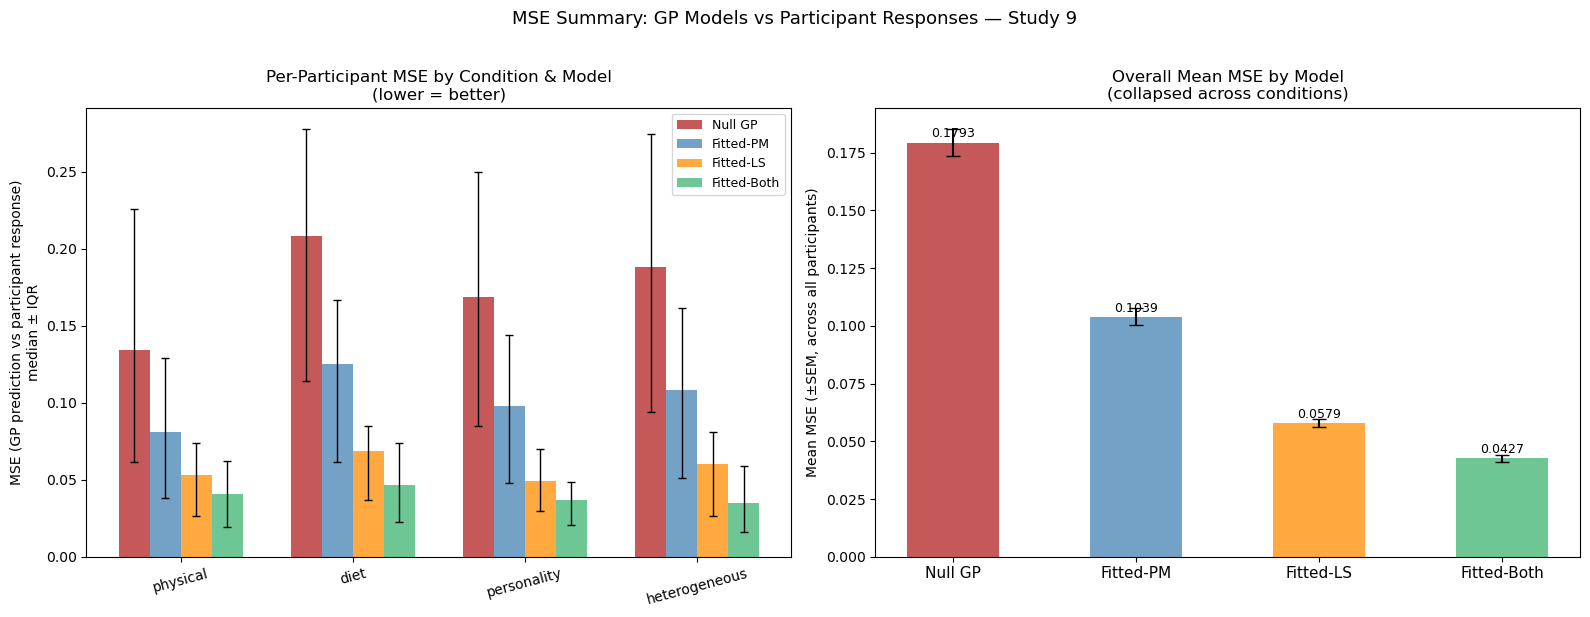

In [53]:
# ── MSE summary: all 4 models, by condition ───────────────────────────────
# MSE = mean((GP_prediction - participant_response)²) per participant,
# then averaged within condition.

cond_order  = ['physical', 'diet', 'personality', 'heterogeneous']
mse_keys    = ['mse_null', 'mse_pm', 'mse_ls', 'mse_both']
mse_labels  = ['Null GP', 'Fitted-PM', 'Fitted-LS', 'Fitted-Both']
mse_colors  = ['firebrick', 'steelblue', 'darkorange', 'mediumseagreen']

# Compute per-participant MSE for each model
for r in results:
    r['mse_null'] = float(np.mean((r['null_preds']        - r['responses']) ** 2))
    r['mse_ls']   = float(np.mean((r['fitted_preds']       - r['responses']) ** 2))
    r['mse_pm']   = float(np.mean((r['fitted_pm_preds']    - r['responses']) ** 2))
    r['mse_both'] = float(np.mean((r['fitted_both_preds']  - r['responses']) ** 2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel 1: Grouped bar chart by condition ───────────────────────────────
ax = axes[0]
n_models = len(mse_keys)
n_conds  = len(cond_order)
x_base   = np.arange(n_conds)
width    = 0.18

for k, (key, label, color) in enumerate(zip(mse_keys, mse_labels, mse_colors)):
    vals_by_cond = [[r[key] for r in results if r['condition'] == c] for c in cond_order]
    medians = [np.median(v) for v in vals_by_cond]
    q25     = [np.percentile(v, 25) for v in vals_by_cond]
    q75     = [np.percentile(v, 75) for v in vals_by_cond]
    x = x_base + (k - 1.5) * width
    ax.bar(x, medians, width, label=label, color=color, alpha=0.75)
    ax.errorbar(x, medians,
                yerr=[np.array(medians) - np.array(q25),
                      np.array(q75)     - np.array(medians)],
                fmt='none', color='black', capsize=3, linewidth=1)

ax.set_xticks(x_base)
ax.set_xticklabels(cond_order, rotation=15)
ax.set_ylabel('MSE (GP prediction vs participant response)\nmedian ± IQR')
ax.set_title('Per-Participant MSE by Condition & Model\n(lower = better)')
ax.legend(fontsize=9)

# ── Panel 2: Mean MSE collapsed across conditions ─────────────────────────
ax = axes[1]
x_pos = np.arange(n_models)
means = [np.mean([r[key] for r in results]) for key in mse_keys]
sems  = [np.std([r[key] for r in results]) / np.sqrt(len(results)) for key in mse_keys]
bars  = ax.bar(x_pos, means, color=mse_colors, alpha=0.75, width=0.5)
ax.errorbar(x_pos, means, yerr=sems, fmt='none', color='black', capsize=5, linewidth=1.5)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, mean + 0.001,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x_pos)
ax.set_xticklabels(mse_labels, fontsize=11)
ax.set_ylabel('Mean MSE (±SEM, across all participants)')
ax.set_title('Overall Mean MSE by Model\n(collapsed across conditions)')

plt.suptitle('MSE Summary: GP Models vs Participant Responses — Study 9', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Print table ───────────────────────────────────────────────────────────
# print(f"\n{'Condition':<16} {'MSE_null':>9} {'MSE_pm':>9} {'MSE_ls':>9} {'MSE_both':>9}  {'%imp_pm':>7}  {'%imp_ls':>7}  {'%imp_both':>9}")
# print('-' * 90)
# for cond in cond_order:
#     cr = [r for r in results if r['condition'] == cond]
#     mn = np.mean([r['mse_null'] for r in cr])
#     ml = np.mean([r['mse_ls']   for r in cr])
#     mp = np.mean([r['mse_pm']   for r in cr])
#     mb = np.mean([r['mse_both'] for r in cr])
#     print(f"{cond:<16} {mn:>9.4f} {mp:>9.4f} {ml:>9.4f} {mb:>9.4f}  {(mn-mp)/mn*100:>6.1f}%  {(mn-ml)/mn*100:>6.1f}%  {(mn-mb)/mn*100:>8.1f}%")
# mn_all = np.mean([r['mse_null'] for r in results])
# ml_all = np.mean([r['mse_ls']   for r in results])
# mp_all = np.mean([r['mse_pm']   for r in results])
# mb_all = np.mean([r['mse_both'] for r in results])
# print('-' * 90)
# print(f"{'ALL':<16} {mn_all:>9.4f} {mp_all:>9.4f} {ml_all:>9.4f} {mb_all:>9.4f}  {(mn_all-mp_all)/mn_all*100:>6.1f}%  {(mn_all-ml_all)/mn_all*100:>6.1f}%  {(mn_all-mb_all)/mn_all*100:>8.1f}%")


# Visualize Participant Belief Predictions

In [85]:
# ── Per-participant visualizer ────────────────────────────────────────────
#
# 5-panel figure (left → right):
#   1. Null GP heatmap         (ls=5.0,        pm=0 fixed)
#   2. Fitted-LS GP heatmap    (ls fit,         pm=0 fixed)
#   3. Fitted-PM GP heatmap    (ls=5.0 fixed,   pm fit)
#   4. Fitted-Both GP heatmap  (ls + pm fit)
#   5. Bar chart: participant | fitted-pm | fitted-ls | fitted-both | null
#
# Heatmap background = GP predicted P(kind-linked)
# Test feature squares  = colored by PARTICIPANT RESPONSE (for direct comparison)
# Panel titles show MSE between GP test-point predictions and participant responses

dark_blue = plt.cm.Blues(1.0)

# Precompute category ordering for bar chart (built once, reused per call)
_feat_to_cat   = df.set_index('feature')['category'].to_dict()
_cat_order     = ['diet_preferences', 'personality_behaviors', 'physical']
_cat_colors    = {'diet_preferences': '#d4edda', 'personality_behaviors': '#cce5ff', 'physical': '#f8d7da'}
_cat_labels    = {'diet_preferences': 'diet', 'personality_behaviors': 'personality', 'physical': 'physical'}

_ordered_cols  = []
_cat_spans     = []
for _cat in _cat_order:
    _cols = [c for c in TEST_COLS if _feat_to_cat.get(CSV_TO_FEATURE[c]) == _cat]
    _cat_spans.append((len(_ordered_cols), len(_ordered_cols) + len(_cols), _cat))
    _ordered_cols.extend(_cols)
_short_names = [CSV_TO_FEATURE[c][:14] for c in _ordered_cols]
_ordered_idx = [TEST_COLS.index(c) for c in _ordered_cols]


def _get_train_info(condition):
    if condition == 'physical':
        mask = (df['category'] == 'physical') & (df['split'] == 'train')
    elif condition == 'diet':
        mask = (df['category'] == 'diet_preferences') & (df['split'] == 'train')
    elif condition == 'personality':
        mask = (df['category'] == 'personality_behaviors') & (df['split'] == 'train')
    elif condition == 'heterogeneous':
        mask = (df['in_heterogenous'] == True) & (df['split'] == 'train')
    else:
        raise ValueError(f"Unknown condition: {condition!r}")
    train_df = df[mask]
    return jnp.array(train_df[['x_2d', 'y_2d']].values), train_df['feature'].tolist()


def _draw_gp_panel(ax, X_tr, y_tr, grid_coords, xx, yy, X_test_arr,
                   kernel_params, prior_mean_val, responses, gp_test_preds,
                   train_names, title):
    """GP heatmap (background) + train circles + test squares colored by participant responses."""
    probs_grid, _, _ = gp.laplace_predict(
        X_tr, y_tr, grid_coords, kernel_params,
        kernel_name='rbf_2d_ard', prior_mean=prior_mean_val
    )
    probs_grid = np.array(probs_grid).reshape(xx.shape)
    mse = float(np.mean((np.array(gp_test_preds) - np.array(responses)) ** 2))

    im = ax.contourf(xx, yy, probs_grid, levels=20, cmap='Blues',
                     alpha=0.75, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label='GP P(kind-linked)', fraction=0.046, pad=0.04)

    ax.scatter(np.array(X_tr)[:, 0], np.array(X_tr)[:, 1],
               c=dark_blue, s=70, edgecolors='black', linewidths=1.5,
               zorder=5, label='train (kind-linked)')
    for j, name in enumerate(train_names):
        ax.annotate(name[:12], (float(X_tr[j, 0]), float(X_tr[j, 1])),
                    fontsize=4.5, alpha=0.75, xytext=(3, 3), textcoords='offset points')

    sc = ax.scatter(np.array(X_test_arr)[:, 0], np.array(X_test_arr)[:, 1],
                    c=responses, cmap='Blues', vmin=0, vmax=1,
                    s=130, marker='s', edgecolors='black', linewidths=1, zorder=6,
                    label='test (participant)')
    plt.colorbar(sc, ax=ax, label='Participant response', fraction=0.046, pad=0.12)

    ax.set_xlim(-0.5, 0.45);  ax.set_ylim(-0.45, 0.35)
    ax.set_xlabel('Embedding Dim 1');  ax.set_ylabel('Embedding Dim 2')
    ax.set_title(f'{title}\nMSE={mse:.4f}', fontsize=9)
    ax.legend(fontsize=6, loc='upper right')


def plot_participant(i, grid_resolution=50):
    """
    5-panel visualizer for participant i.
    Panels 1-4: heatmaps for null / fitted-ls / fitted-pm / fitted-both
    Panel 5:    bar chart comparing all 4 models + participant responses
    """
    r                 = results[i]
    cond              = r['condition']
    responses         = r['responses']
    fitted_ls         = r['fitted_ls']
    fitted_preds      = r['fitted_preds']
    fitted_pm_pm      = r['fitted_pm_pm']
    fitted_pm_preds   = r['fitted_pm_preds']
    fitted_both_ls    = r['fitted_both_ls']
    fitted_both_pm    = r['fitted_both_pm']
    fitted_both_preds = r['fitted_both_preds']
    null_preds        = r['null_preds']
    delta_ll          = r['delta_ll']
    delta_ll_pm       = r['delta_ll_pm']
    delta_ll_both     = r['delta_ll_both']
    r_val             = r['r_fitted']
    r_pm_val          = r['r_pm']
    r_both_val        = r['r_both']

    X_tr, y_tr = get_condition_train(cond)
    _, train_names = _get_train_info(cond)

    xx, yy = np.meshgrid(
        np.linspace(-0.5, 0.45, grid_resolution),
        np.linspace(-0.45, 0.35, grid_resolution)
    )
    grid_coords = jnp.array(np.stack([xx.ravel(), yy.ravel()], axis=1))

    null_kp        = jnp.array([GP_SIGMA, NULL_LS,        NULL_LS       ])
    fitted_kp      = jnp.array([GP_SIGMA, fitted_ls,      fitted_ls     ])
    fitted_pm_kp   = jnp.array([GP_SIGMA, NULL_LS,        NULL_LS       ])  # same ls as null
    fitted_both_kp = jnp.array([GP_SIGMA, fitted_both_ls, fitted_both_ls])

    fig, axes = plt.subplots(1, 5, figsize=(32, 6))
    ax1, ax2, ax3, ax4, ax5 = axes

    _draw_gp_panel(ax1, X_tr, y_tr, grid_coords, xx, yy, np.array(X_test),
                   null_kp, PRIOR_MEAN, responses, null_preds, train_names,
                   title=f'Null GP  (ls={NULL_LS},  pm=0)')

    _draw_gp_panel(ax3, X_tr, y_tr, grid_coords, xx, yy, np.array(X_test),
                   fitted_kp, PRIOR_MEAN, responses, fitted_preds, train_names,
                   title=f'Fitted-LS GP  (ls={fitted_ls:.3f},  pm=0)')

    _draw_gp_panel(ax2, X_tr, y_tr, grid_coords, xx, yy, np.array(X_test),
                   fitted_pm_kp, fitted_pm_pm, responses, fitted_pm_preds, train_names,
                   title=f'Fitted-PM GP  (ls={NULL_LS},  pm={fitted_pm_pm:.2f})')

    _draw_gp_panel(ax4, X_tr, y_tr, grid_coords, xx, yy, np.array(X_test),
                   fitted_both_kp, fitted_both_pm, responses, fitted_both_preds, train_names,
                   title=f'Fitted-Both GP  (ls={fitted_both_ls:.3f},  pm={fitted_both_pm:.2f})')

    # ── Bar chart ──────────────────────────────────────────────────────────
    x_pos = np.arange(len(_ordered_cols))
    width = 0.16

    resp_ord        = responses[_ordered_idx]
    fitted_ord      = fitted_preds[_ordered_idx]
    fitted_pm_ord   = fitted_pm_preds[_ordered_idx]
    fitted_both_ord = fitted_both_preds[_ordered_idx]
    null_ord        = null_preds[_ordered_idx]

    for start, end, cat in _cat_spans:
        ax5.axvspan(start - 0.5, end - 0.5, alpha=0.12, color=_cat_colors[cat], zorder=0)
        ax5.text((start + end) / 2 - 0.5, 0.97, _cat_labels[cat],
                 ha='center', va='top', fontsize=8, color='gray',
                 transform=ax5.get_xaxis_transform())

    ax5.bar(x_pos - 2*width, resp_ord,        width, label='participant',      color='steelblue',      alpha=0.85)
    ax5.bar(x_pos - 1*width, fitted_pm_ord,   width, label='fitted-pm GP',     color='cornflowerblue', alpha=0.85)
    ax5.bar(x_pos + 0*width, fitted_ord,       width, label='fitted-ls GP',     color='darkorange',     alpha=0.85)
    ax5.bar(x_pos + 1*width, fitted_both_ord,  width, label='fitted-both GP',   color='mediumseagreen', alpha=0.85)
    ax5.bar(x_pos + 2*width, null_ord,         width, label='null GP',
            color='white', edgecolor='firebrick', linewidth=1.2, alpha=0.9)

    for start, _, _ in _cat_spans[1:]:
        ax5.axvline(x=start - 0.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)

    ax5.axhline(0.5, color='gray', linestyle=':', linewidth=1)
    ax5.set_xticks(x_pos)
    ax5.set_xticklabels(_short_names, rotation=45, ha='right', fontsize=7)
    ax5.set_ylim(0, 1.05)
    ax5.set_ylabel('P(kind-linked)')
    ax5.legend(fontsize=7, loc='upper right')

    def fmt(v): return f'{v:.2f}' if not np.isnan(v) else 'n/a'
    ax5.set_title(
        f'Participant {i}  |  condition: {cond}\n'
        f'r: ls={fmt(r_val)}, pm={fmt(r_pm_val)}, both={fmt(r_both_val)}\n'
        f'Δll: ls={delta_ll:.1f}, pm={delta_ll_pm:.1f}, both={delta_ll_both:.1f}',
        fontsize=9
    )

    plt.suptitle(f'Study 9 — Participant {i} ({cond})', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


print("plot_participant(i) defined. Call with any index 0 –", len(results) - 1)


plot_participant(i) defined. Call with any index 0 – 401


/var/folders/qb/4f5th4w557qd4b1rmp7v8lxm0000gq/T/ipykernel_70615/707983026.py:62: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(np.array(X_tr)[:, 0], np.array(X_tr)[:, 1],


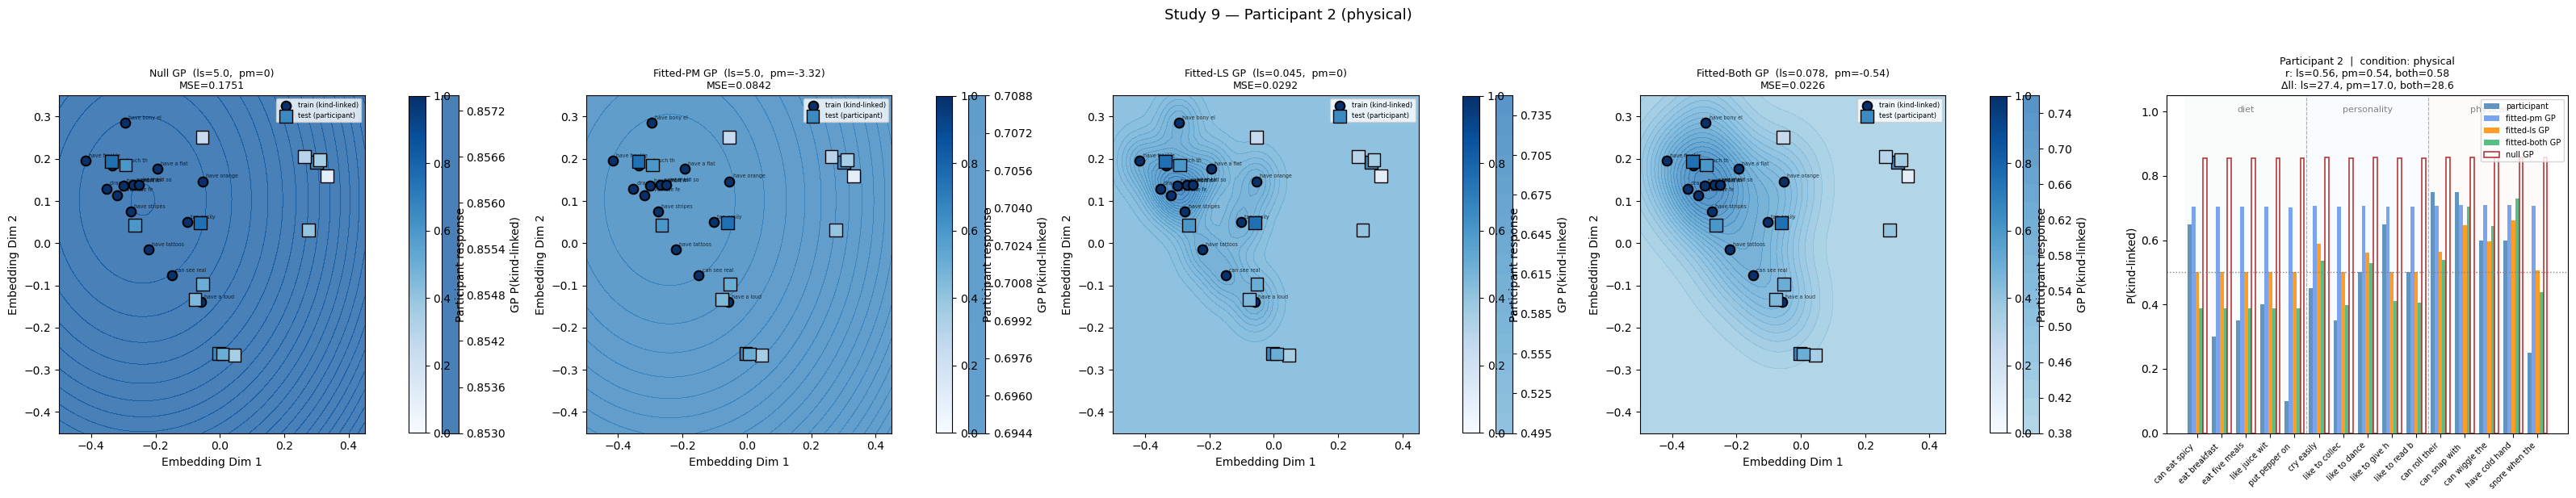

In [86]:
# ── Example: plot a specific participant ─────────────────────────────────
# Change i to any index 0 – len(results)-1

plot_participant(2)

total log likelihood for each model w/ each participants (can sum MLE) and do log likelihood ratio test b/c nested models (compare fitting only prior mean + mean and length scale)

plot_all_conditions_summary() defined.


/var/folders/qb/4f5th4w557qd4b1rmp7v8lxm0000gq/T/ipykernel_70615/3921966889.py:53: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(np.array(X_tr)[:, 0], np.array(X_tr)[:, 1],
/var/folders/qb/4f5th4w557qd4b1rmp7v8lxm0000gq/T/ipykernel_70615/3921966889.py:53: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(np.array(X_tr)[:, 0], np.array(X_tr)[:, 1],
/var/folders/qb/4f5th4w557qd4b1rmp7v8lxm0000gq/T/ipykernel_7

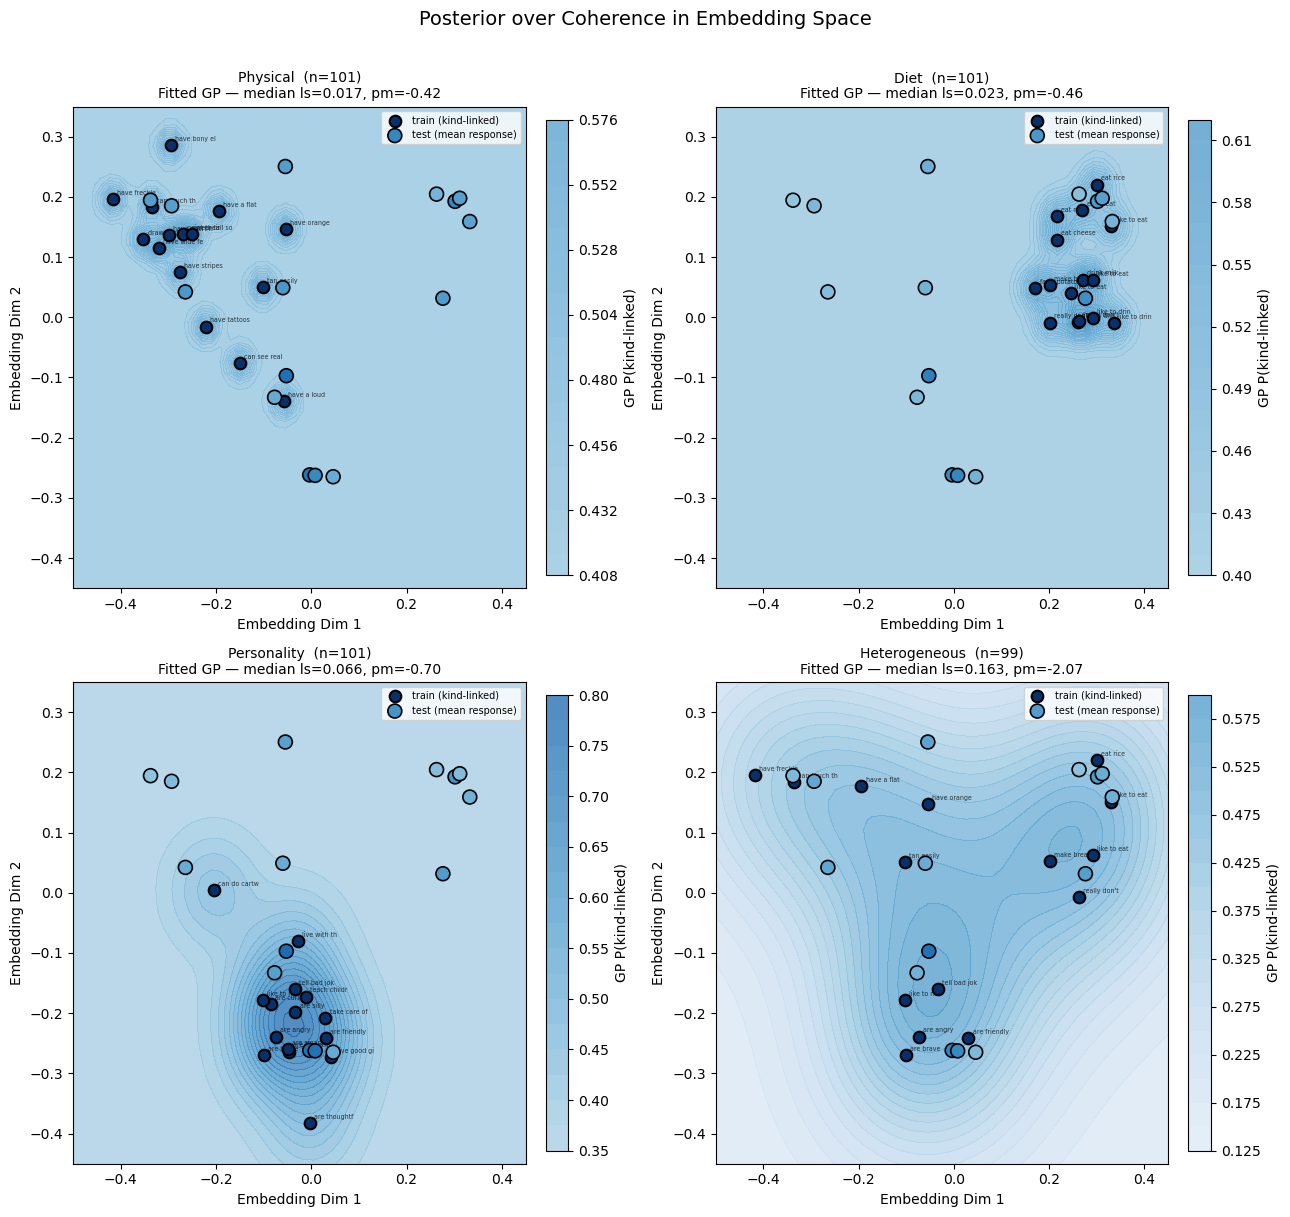

In [87]:
# ── Summary visualizer: all 4 conditions ─────────────────────────────────
#
# Layout: 2×2 grid, one panel per condition
#   Background heatmap = GP P(kind-linked) using median fitted-both hyperparams
#   Train features     = filled circles (steelblue)
#   Test features      = filled circles colored by mean participant prevalence judgment
#                        (or open transparent circles if color_test_by_response=False)

def plot_all_conditions_summary(grid_resolution=50, color_test_by_response=True):
    """
    2×2 summary figure, one panel per condition (physical, diet, personality, heterogeneous).
    Each panel: GP heatmap (fitted-both) using condition-median hyperparams.
    Train features = filled blue circles.
    Test features  = filled circles colored by mean participant response (if color_test_by_response=True).
    """
    cond_order  = ['physical', 'diet', 'personality', 'heterogeneous']
    cond_labels = {'physical': 'Physical', 'diet': 'Diet',
                   'personality': 'Personality', 'heterogeneous': 'Heterogeneous'}

    xx, yy = np.meshgrid(
        np.linspace(-0.5, 0.45, grid_resolution),
        np.linspace(-0.45, 0.35, grid_resolution)
    )
    grid_coords = jnp.array(np.stack([xx.ravel(), yy.ravel()], axis=1))

    fig, axes = plt.subplots(2, 2, figsize=(13, 12))

    for idx, cond in enumerate(cond_order):
        ax  = axes[idx // 2, idx % 2]
        cr  = [r for r in results if r['condition'] == cond]
        n   = len(cr)

        # Median hyperparams for the heatmap
        med_ls = float(np.median([r['fitted_both_ls'] for r in cr]))
        med_pm = float(np.median([r['fitted_both_pm'] for r in cr]))
        kp     = jnp.array([GP_SIGMA, med_ls, med_ls])

        X_tr, y_tr     = get_condition_train(cond)
        _, train_names = _get_train_info(cond)

        # GP heatmap
        probs_grid, _, _ = gp.laplace_predict(
            X_tr, y_tr, grid_coords, kp,
            kernel_name='rbf_2d_ard', prior_mean=med_pm
        )
        probs_grid = np.array(probs_grid).reshape(xx.shape)

        im = ax.contourf(xx, yy, probs_grid, levels=20, cmap='Blues',
                         alpha=0.75, vmin=0, vmax=1)
        plt.colorbar(im, ax=ax, label='GP P(kind-linked)', fraction=0.046, pad=0.04)

        # Train features — filled circles
        ax.scatter(np.array(X_tr)[:, 0], np.array(X_tr)[:, 1],
                   c=dark_blue, s=70, edgecolors='black', linewidths=1.5,
                   zorder=5, label='train (kind-linked)')
        for j, name in enumerate(train_names):
            ax.annotate(name[:12], (float(X_tr[j, 0]), float(X_tr[j, 1])),
                        fontsize=4.5, alpha=0.75, xytext=(3, 3),
                        textcoords='offset points')

        # Test features
        X_test_np = np.array(X_test)
        if color_test_by_response:
            mean_resp = np.mean([r['responses'] for r in cr], axis=0)  # (15,)
            sc = ax.scatter(X_test_np[:, 0], X_test_np[:, 1],
                            c=mean_resp, cmap='Blues', vmin=0, vmax=1,
                            s=100, edgecolors='black', linewidths=1.2,
                            zorder=6, label='test (mean response)')
        else:
            ax.scatter(X_test_np[:, 0], X_test_np[:, 1],
                       facecolors='none', edgecolors='black', linewidths=1.2,
                       s=80, alpha=0.5, zorder=6, label='test features')

        ax.set_xlim(-0.5, 0.45);  ax.set_ylim(-0.45, 0.35)
        ax.set_xlabel('Embedding Dim 1')
        ax.set_ylabel('Embedding Dim 2')
        ax.set_title(
            f'{cond_labels[cond]}  (n={n})\n'
            f'Fitted GP — median ls={med_ls:.3f}, pm={med_pm:.2f}',
            fontsize=10
        )
        ax.legend(fontsize=7, loc='upper right')

    plt.suptitle('Posterior over Coherence in Embedding Space', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


print("plot_all_conditions_summary() defined.")
plot_all_conditions_summary()

/var/folders/qb/4f5th4w557qd4b1rmp7v8lxm0000gq/T/ipykernel_70615/3921966889.py:53: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(np.array(X_tr)[:, 0], np.array(X_tr)[:, 1],
/var/folders/qb/4f5th4w557qd4b1rmp7v8lxm0000gq/T/ipykernel_70615/3921966889.py:53: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(np.array(X_tr)[:, 0], np.array(X_tr)[:, 1],
/var/folders/qb/4f5th4w557qd4b1rmp7v8lxm0000gq/T/ipykernel_7

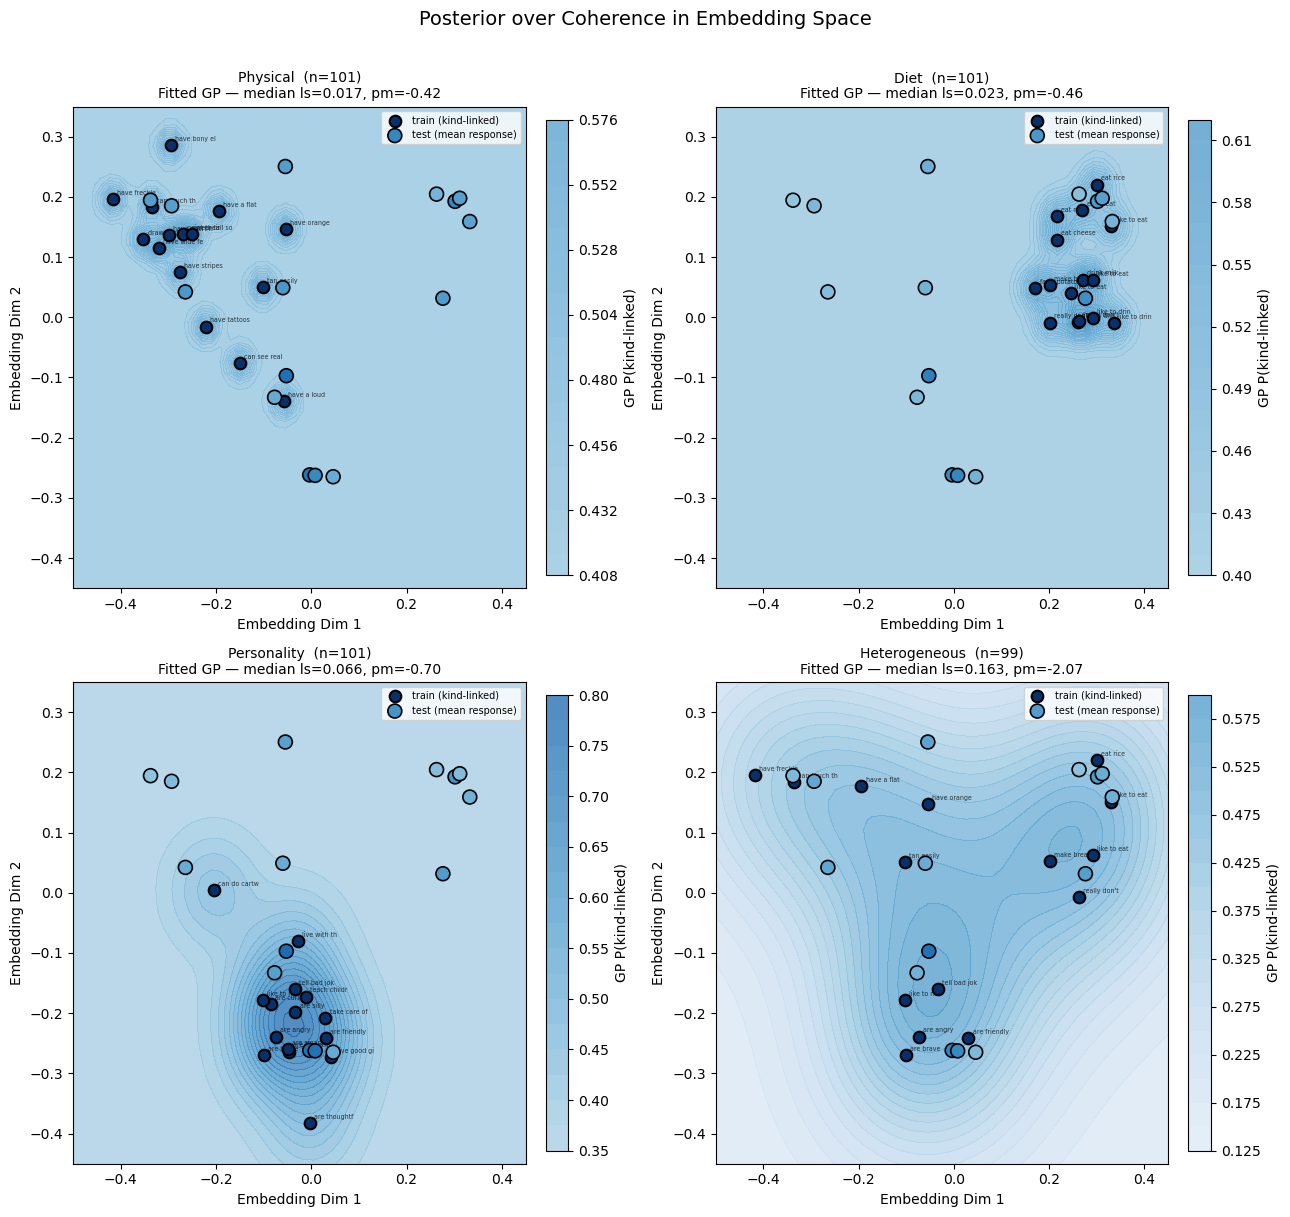

In [88]:
plot_all_conditions_summary()

if we want to explain variability between conditions, it's ok that some params are fit across all conditions (b/c they should be invariant across conditions) and the thing we do care about (lengthscale, generalization) is fit within participant which is also within condition

distribution of length scales under each condition ; change colorscale to be unipolar

fit prior mean first (across all)
then fit individual lengthscales per participant


then aggregate across conditions

shorter down the line; linking function

longer down the line;  
perhaps jointly optimizing betas for linking, by participant, population lvl, and by item (feature)

In [58]:
# Per-participant coherence θ (mean GP P(kind-linked) across all test features)
# θ is a single category-wide coherence estimate ("probability any feature is kind-linked")

for r in results:
    r['theta_null']  = float(np.mean(r['null_preds']))
    r['theta_pm']    = float(np.mean(r['fitted_pm_preds']))
    r['theta_ls']    = float(np.mean(r['fitted_preds']))
    r['theta_both']  = float(np.mean(r['fitted_both_preds']))

# Summarize θ by condition
for model_key, label in [('theta_null','null'), ('theta_pm','fitted-pm'),
                          ('theta_ls','fitted-ls'), ('theta_both','fitted-both')]:
    print(f"\nθ ({label}):")
    for cond in ['physical', 'diet', 'personality', 'heterogeneous']:
        vals = [r[model_key] for r in results if r['condition'] == cond]
        print(f"  {cond:<16}  mean={np.mean(vals):.3f}  std={np.std(vals):.3f}")



θ (null):
  physical          mean=0.856  std=0.000
  diet              mean=0.856  std=0.000
  personality       mean=0.856  std=0.000
  heterogeneous     mean=0.857  std=0.000

θ (fitted-pm):
  physical          mean=0.752  std=0.099
  diet              mean=0.737  std=0.074
  personality       mean=0.732  std=0.065
  heterogeneous     mean=0.738  std=0.077

θ (fitted-ls):
  physical          mean=0.609  std=0.136
  diet              mean=0.586  std=0.132
  personality       mean=0.605  std=0.118
  heterogeneous     mean=0.595  std=0.124

θ (fitted-both):
  physical          mean=0.594  std=0.212
  diet              mean=0.529  std=0.198
  personality       mean=0.554  std=0.177
  heterogeneous     mean=0.543  std=0.203


# Fixing Prior Mean and Fitting Lengthscales per Participant

Population MLE prior mean: -3.317  (sigmoid → 0.035 baseline P(kind-linked))
Grid index 17 / 199


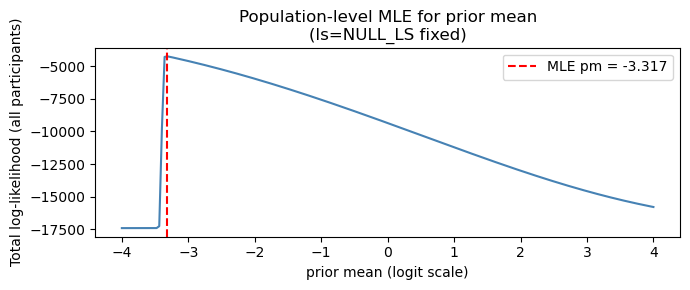

In [64]:
# ── Step 1: Fit population-level prior mean (MLE across all participants) ─────
#
# We fix ls=NULL_LS and find the single prior_mean that maximises the total
# log-likelihood summed over all participants.  This treats pm as a shared
# population parameter (invariant across conditions) and ls as the
# individual-level parameter of interest.
#
# For each pm candidate, total_ll(pm) = Σ_i Σ_j log N(r_ij | GP_prob_j(pm), σ)
# where GP_prob_j(pm) depends on participant i's condition.

from scipy.stats import norm as sp_norm

# condition_grids_pm already holds (N_PM_GRID, 15) predictions per condition
# pm_grid is the shared grid

total_ll_pm = np.zeros(N_PM_GRID)
for p in participants:
    cond      = p['condition']
    responses = p['responses']
    grid_pm   = condition_grids_pm[cond]   # (N_PM_GRID, 15)
    lls_pm    = np.sum(sp_norm.logpdf(responses[None, :], loc=grid_pm, scale=SIGMA_NOISE), axis=1)
    total_ll_pm += lls_pm   # sum log-likelihoods across participants

best_pm_pop_idx = int(np.argmax(total_ll_pm))
pm_population   = float(pm_grid[best_pm_pop_idx])

print(f"Population MLE prior mean: {pm_population:.3f}  "
      f"(sigmoid → {1/(1+np.exp(-pm_population)):.3f} baseline P(kind-linked))")
print(f"Grid index {best_pm_pop_idx} / {N_PM_GRID-1}")

# Quick plot: total log-likelihood profile over pm
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(pm_grid, total_ll_pm, color='steelblue')
ax.axvline(pm_population, color='red', linestyle='--', label=f'MLE pm = {pm_population:.3f}')
ax.set_xlabel('prior mean (logit scale)')
ax.set_ylabel('Total log-likelihood (all participants)')
ax.set_title('Population-level MLE for prior mean\n(ls=NULL_LS fixed)')
ax.legend()
plt.tight_layout()
plt.show()

physical: null_pop range=[0.703, 0.709],  ls_pop_grid shape=(500, 15)
diet: null_pop range=[0.702, 0.709],  ls_pop_grid shape=(500, 15)
personality: null_pop range=[0.703, 0.709],  ls_pop_grid shape=(500, 15)
heterogeneous: null_pop range=[0.707, 0.709],  ls_pop_grid shape=(500, 15)

Grids at population pm complete.
Population pm = -3.317  (sigmoid → 0.035)

Condition           n   mean LLR   med LLR   % p<.05   % FDR<.05   agg LLR       agg p
----------------------------------------------------------------------------------
physical          101     12.397     4.760     52.5%       51.5%   1252.09  8.853e-198
diet              101     19.949    14.092     69.3%       68.3%   2014.85           0
personality       101     19.123    15.490     68.3%       68.3%   1931.43           0
heterogeneous      99     23.649    13.109     69.7%       68.7%   2341.25           0
----------------------------------------------------------------------------------
ALL               402     18.755    11

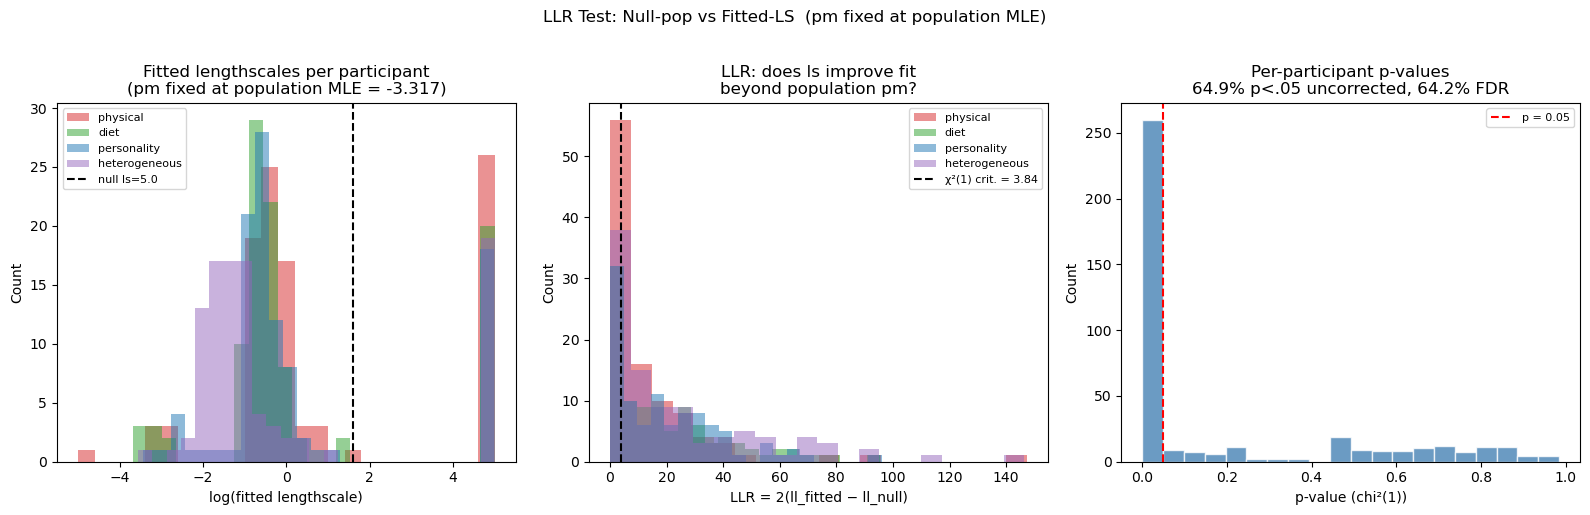

In [65]:
# ── Step 2: Precompute GP grids with population prior mean fixed ───────────
#
# We need two grids per condition at pm=pm_population:
#   (a) null_pop:   (15,)           predictions at ls=NULL_LS, pm=pm_population
#   (b) ls_pop_grid:(N_LS_GRID, 15) predictions at each ls, pm=pm_population

null_kp_pop = jnp.array([GP_SIGMA, NULL_LS, NULL_LS])

condition_null_pop  = {}   # cond -> (15,)
condition_ls_pop    = {}   # cond -> (N_LS_GRID, 15)

for cond in ['physical', 'diet', 'personality', 'heterogeneous']:
    X_tr, y_tr = get_condition_train(cond)

    # Null at population pm
    null_probs, _, _ = gp.laplace_predict(
        X_tr, y_tr, X_test, null_kp_pop,
        kernel_name='rbf_2d_ard', prior_mean=pm_population
    )
    condition_null_pop[cond] = np.array(null_probs)   # (15,)

    # LS grid at population pm
    batch_probs, _, _ = gp.laplace_predict_batch(
        X_tr, y_tr, X_test, kp_grid,
        kernel_name='rbf_2d_ard', prior_mean=pm_population
    )
    condition_ls_pop[cond] = np.array(batch_probs)    # (N_LS_GRID, 15)

    print(f"{cond}: null_pop range=[{condition_null_pop[cond].min():.3f}, "
          f"{condition_null_pop[cond].max():.3f}],  ls_pop_grid shape={condition_ls_pop[cond].shape}")

print("\nGrids at population pm complete.")

# ── Step 3: Fit lengthscale per participant (pm fixed at pm_population) ────
#
# Two models (both with pm=pm_population):
#   Null-pop   (k=0): ls=NULL_LS fixed  → null_pop_ll
#   Fitted-pop (k=1): ls optimized      → fitted_pop_ll, fitted_pop_ls
#
# LLR = 2*(fitted_pop_ll - null_pop_ll) ~ chi²(df=1) under H0

from scipy.stats import chi2
from statsmodels.stats.multitest import multipletests

pop_results = []
for p in participants:
    cond      = p['condition']
    responses = p['responses']

    # Null-pop
    null_preds_pop = condition_null_pop[cond]
    null_pop_ll    = float(np.sum(sp_norm.logpdf(responses, loc=null_preds_pop, scale=SIGMA_NOISE)))

    # Fitted-pop: argmax over ls grid
    grid_pop = condition_ls_pop[cond]   # (N_LS_GRID, 15)
    lls_pop  = np.sum(sp_norm.logpdf(responses[None, :], loc=grid_pop, scale=SIGMA_NOISE), axis=1)
    best_idx_pop   = int(np.argmax(lls_pop))
    fitted_pop_ls  = float(ls_grid[best_idx_pop])
    fitted_pop_ll  = float(lls_pop[best_idx_pop])
    fitted_pop_preds = grid_pop[best_idx_pop]   # (15,)

    pop_results.append({
        'condition':       cond,
        'responses':       responses,
        'null_pop_ll':     null_pop_ll,
        'fitted_pop_ll':   fitted_pop_ll,
        'fitted_pop_ls':   fitted_pop_ls,
        'fitted_pop_preds': fitted_pop_preds,
        'delta_ll_pop':    fitted_pop_ll - null_pop_ll,
    })

# ── LLR test ───────────────────────────────────────────────────────────────
llr_pop    = np.array([2 * r['delta_ll_pop'] for r in pop_results])
pvals_pop  = chi2.sf(llr_pop, df=1)
conds_pop  = np.array([r['condition'] for r in pop_results])

_, pvals_pop_fdr, _, _ = multipletests(pvals_pop, method='fdr_bh')

for r, lv, pv, pv_fdr in zip(pop_results, llr_pop, pvals_pop, pvals_pop_fdr):
    r['llr']         = float(lv)
    r['llr_pval']    = float(pv)
    r['llr_pval_fdr']= float(pv_fdr)
    r['llr_sig']     = pv     < 0.05
    r['llr_sig_fdr'] = pv_fdr < 0.05

# ── Summary table ──────────────────────────────────────────────────────────
N_pop = len(pop_results)
print(f"Population pm = {pm_population:.3f}  (sigmoid → {1/(1+np.exp(-pm_population)):.3f})\n")
print(f"{'Condition':<16} {'n':>4}  {'mean LLR':>9}  {'med LLR':>8}  "
      f"{'% p<.05':>8}  {'% FDR<.05':>10}  {'agg LLR':>8}  {'agg p':>10}")
print('-' * 82)
for cond in ['physical', 'diet', 'personality', 'heterogeneous']:
    idx = conds_pop == cond
    lv  = llr_pop[idx];  pv = pvals_pop[idx]
    agg_llr = lv.sum()
    agg_p   = chi2.sf(agg_llr, df=idx.sum())
    print(f"{cond:<16} {idx.sum():>4}  {lv.mean():>9.3f}  {np.median(lv):>8.3f}  "
          f"{100*np.mean(pv < 0.05):>7.1f}%  {100*np.mean(pvals_pop_fdr[idx] < 0.05):>9.1f}%  "
          f"{agg_llr:>8.2f}  {agg_p:>10.4g}")

agg_llr_all = llr_pop.sum()
agg_p_all   = chi2.sf(agg_llr_all, df=N_pop)
print('-' * 82)
print(f"{'ALL':<16} {N_pop:>4}  {llr_pop.mean():>9.3f}  {np.median(llr_pop):>8.3f}  "
      f"{100*np.mean(pvals_pop < 0.05):>7.1f}%  {100*np.mean(pvals_pop_fdr < 0.05):>9.1f}%  "
      f"{agg_llr_all:>8.2f}  {agg_p_all:>10.4g}")
print(f"\nAggregate LLR (all {N_pop} participants): {agg_llr_all:.2f}, chi²(df={N_pop}), p={agg_p_all:.4g}")

# ── Visualization ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cond_colors = {'physical': 'tab:red', 'diet': 'tab:green',
               'personality': 'tab:blue', 'heterogeneous': 'tab:purple'}

# Panel 1: Distribution of fitted lengthscales by condition
ax = axes[0]
for cond in ['physical', 'diet', 'personality', 'heterogeneous']:
    ls_vals = [r['fitted_pop_ls'] for r in pop_results if r['condition'] == cond]
    ax.hist(np.log(ls_vals), bins=25, alpha=0.5, label=cond, color=cond_colors[cond])
ax.axvline(np.log(NULL_LS), color='black', linestyle='--', linewidth=1.5,
           label=f'null ls={NULL_LS}')
ax.set_xlabel('log(fitted lengthscale)')
ax.set_ylabel('Count')
ax.set_title(f'Fitted lengthscales per participant\n(pm fixed at population MLE = {pm_population:.3f})')
ax.legend(fontsize=8)

# Panel 2: LLR distribution by condition
ax = axes[1]
for cond in ['physical', 'diet', 'personality', 'heterogeneous']:
    idx = conds_pop == cond
    ax.hist(llr_pop[idx], bins=20, alpha=0.5, label=cond, color=cond_colors[cond])
ax.axvline(chi2.ppf(0.95, df=1), color='black', linestyle='--', linewidth=1.5,
           label=f'χ²(1) crit. = {chi2.ppf(0.95,df=1):.2f}')
ax.set_xlabel('LLR = 2(ll_fitted − ll_null)')
ax.set_ylabel('Count')
ax.set_title('LLR: does ls improve fit\nbeyond population pm?')
ax.legend(fontsize=8)

# Panel 3: p-value histogram
ax = axes[2]
ax.hist(pvals_pop, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0.05, color='red', linestyle='--', linewidth=1.5, label='p = 0.05')
ax.set_xlabel('p-value (chi²(1))')
ax.set_ylabel('Count')
ax.set_title(f'Per-participant p-values\n'
             f'{np.mean(pvals_pop < 0.05)*100:.1f}% p<.05 uncorrected, '
             f'{np.mean(pvals_pop_fdr < 0.05)*100:.1f}% FDR')
ax.legend(fontsize=8)

plt.suptitle('LLR Test: Null-pop vs Fitted-LS  (pm fixed at population MLE)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

/var/folders/qb/4f5th4w557qd4b1rmp7v8lxm0000gq/T/ipykernel_70615/3207672722.py:41: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(np.array(X_tr)[:, 0], np.array(X_tr)[:, 1],
/var/folders/qb/4f5th4w557qd4b1rmp7v8lxm0000gq/T/ipykernel_70615/3207672722.py:41: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(np.array(X_tr)[:, 0], np.array(X_tr)[:, 1],
/var/folders/qb/4f5th4w557qd4b1rmp7v8lxm0000gq/T/ipykernel_7

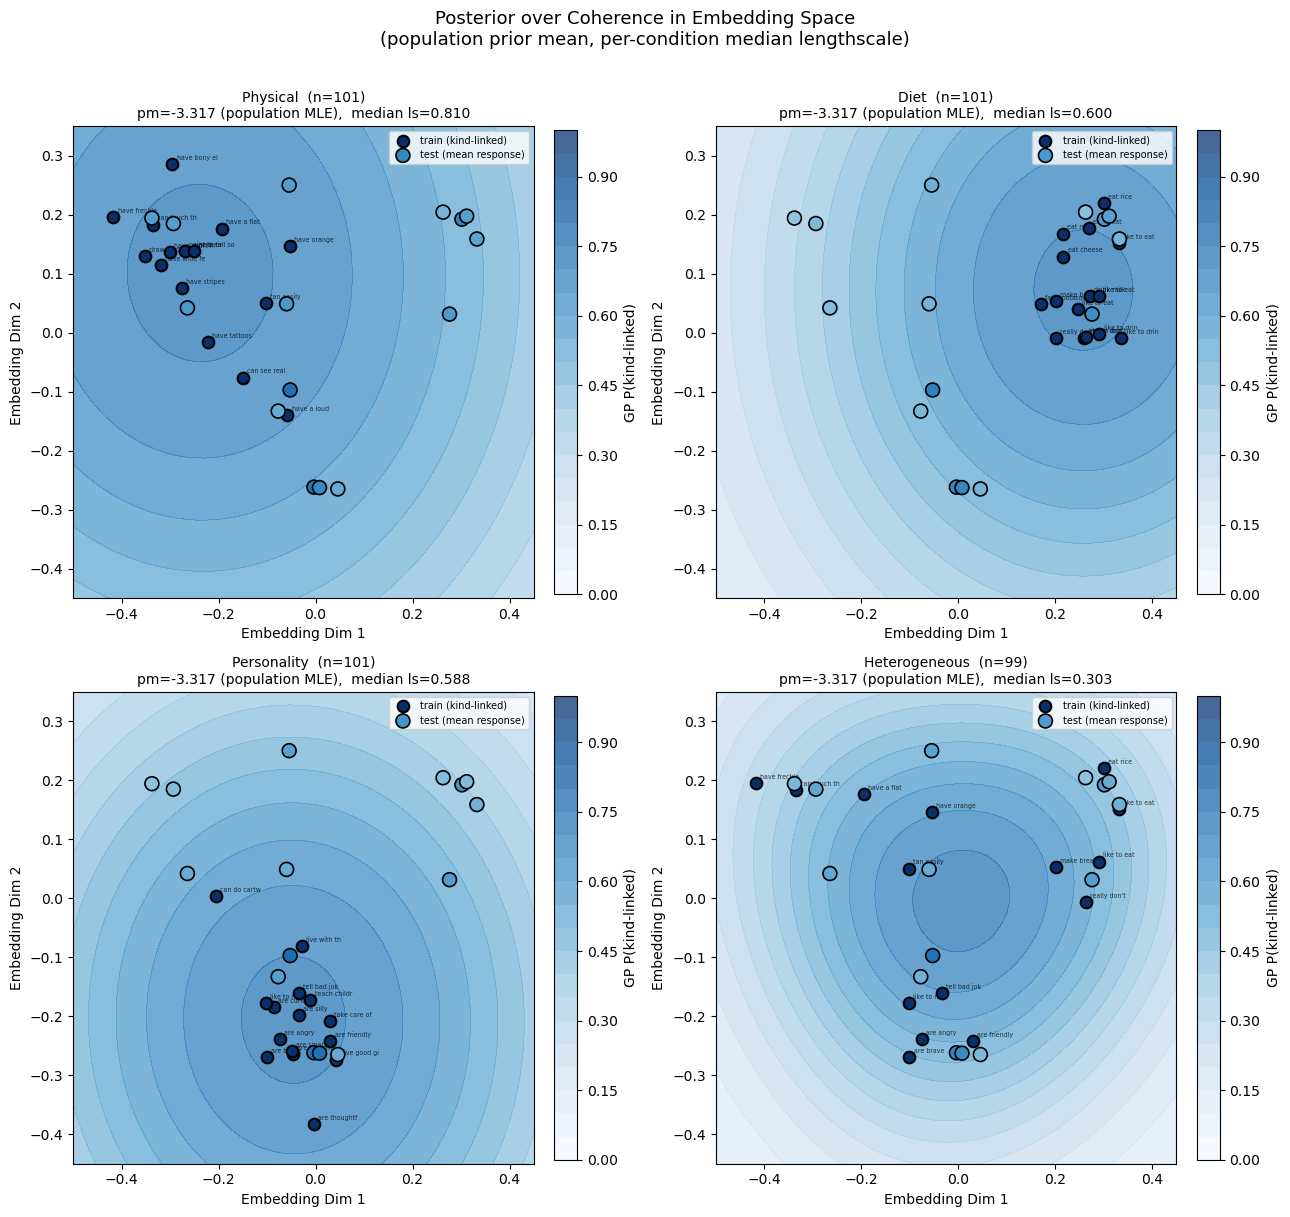

In [89]:
# ── Summary heatmap: all 4 conditions using population pm + per-participant median ls ──
#
# Same layout as plot_all_conditions_summary() but using:
#   pm  = pm_population  (fixed, shared across all participants)
#   ls  = median fitted_pop_ls per condition

def plot_pop_conditions_summary(grid_resolution=50, color_test_by_response=True):
    cond_order  = ['physical', 'diet', 'personality', 'heterogeneous']
    cond_labels = {'physical': 'Physical', 'diet': 'Diet',
                   'personality': 'Personality', 'heterogeneous': 'Heterogeneous'}

    xx, yy = np.meshgrid(
        np.linspace(-0.5, 0.45, grid_resolution),
        np.linspace(-0.45, 0.35, grid_resolution)
    )
    grid_coords = jnp.array(np.stack([xx.ravel(), yy.ravel()], axis=1))

    fig, axes = plt.subplots(2, 2, figsize=(13, 12))

    for idx, cond in enumerate(cond_order):
        ax = axes[idx // 2, idx % 2]
        cr = [r for r in pop_results if r['condition'] == cond]
        n  = len(cr)

        med_ls = float(np.median([r['fitted_pop_ls'] for r in cr]))
        kp     = jnp.array([GP_SIGMA, med_ls, med_ls])

        X_tr, y_tr     = get_condition_train(cond)
        _, train_names = _get_train_info(cond)

        probs_grid, _, _ = gp.laplace_predict(
            X_tr, y_tr, grid_coords, kp,
            kernel_name='rbf_2d_ard', prior_mean=pm_population
        )
        probs_grid = np.array(probs_grid).reshape(xx.shape)

        im = ax.contourf(xx, yy, probs_grid, levels=np.linspace(0, 1, 21), cmap='Blues',
                         alpha=0.75, vmin=0, vmax=1)
        plt.colorbar(im, ax=ax, label='GP P(kind-linked)', fraction=0.046, pad=0.04)

        ax.scatter(np.array(X_tr)[:, 0], np.array(X_tr)[:, 1],
                   c=dark_blue, s=70, edgecolors='black', linewidths=1.5,
                   zorder=5, label='train (kind-linked)')
        for j, name in enumerate(train_names):
            ax.annotate(name[:12], (float(X_tr[j, 0]), float(X_tr[j, 1])),
                        fontsize=4.5, alpha=0.75, xytext=(3, 3), textcoords='offset points')

        X_test_np = np.array(X_test)
        if color_test_by_response:
            mean_resp = np.mean([r['responses'] for r in cr], axis=0)  # (15,)
            ax.scatter(X_test_np[:, 0], X_test_np[:, 1],
                       c=mean_resp, cmap='Blues', vmin=0, vmax=1,
                       s=100, edgecolors='black', linewidths=1.2,
                       zorder=6, label='test (mean response)')
        else:
            ax.scatter(X_test_np[:, 0], X_test_np[:, 1],
                       facecolors='none', edgecolors='black', linewidths=1.2,
                       s=80, alpha=0.5, zorder=6, label='test features')

        ax.set_xlim(-0.5, 0.45);  ax.set_ylim(-0.45, 0.35)
        ax.set_xlabel('Embedding Dim 1')
        ax.set_ylabel('Embedding Dim 2')
        ax.set_title(
            f'{cond_labels[cond]}  (n={n})\n'
            f'pm={pm_population:.3f} (population MLE),  median ls={med_ls:.3f}',
            fontsize=10
        )
        ax.legend(fontsize=7, loc='upper right')

    plt.suptitle('Posterior over Coherence in Embedding Space\n'
                 '(population prior mean, per-condition median lengthscale)',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

plot_pop_conditions_summary()

# Linking Function w/ Fitted Betas

In [90]:
from scipy.optimize import minimize
from scipy.stats import beta as beta_dist

def fit_beta_mixture(responses_j, weights):
    """
    Fit Beta mixture with fixed weights: r ~ p(z'=1)·Beta(a1,b1) + p(z'=0)·Beta(a2,b2)
    responses_j: (N,) in [0,1]; weights: (N,) in [0,1] — p(z'_j=1) per participant for feature j
    Returns: (alpha_kl, beta_kl, alpha_nkl, beta_nkl)
    """
    eps = 1e-6
    r   = np.clip(responses_j, eps, 1 - eps)
    th  = np.array(weights)

    def neg_ll(params):
        a1, b1, a2, b2 = params
        pdf1 = beta_dist.pdf(r, a1, b1)
        pdf2 = beta_dist.pdf(r, a2, b2)
        mixture = th * pdf1 + (1 - th) * pdf2
        return -np.sum(np.log(np.clip(mixture, 1e-300, None)))

    # Try multiple initializations to avoid local optima
    best = None
    for init in [(5, 1, 1, 5), (3, 1, 1, 3), (8, 2, 2, 5), (2, 2, 2, 2)]:
        res = minimize(neg_ll, x0=init, method='L-BFGS-B',
                       bounds=[(0.1, 50)] * 4)
        if best is None or res.fun < best.fun:
            best = res

    a1, b1, a2, b2 = best.x
    # Enforce labeling: alpha_kl = high-prevalence Beta (mean > 0.5)
    mean1 = a1 / (a1 + b1)
    mean2 = a2 / (a2 + b2)
    if mean1 >= mean2:
        return dict(alpha_kl=a1, beta_kl=b1, alpha_nkl=a2, beta_nkl=b2)
    else:
        return dict(alpha_kl=a2, beta_kl=b2, alpha_nkl=a1, beta_nkl=b1)


# Fit using per-feature p(z'_j=1) weights from fitted-both GP
# w_j[i] = GP's predicted P(kind-linked) for feature j, participant i
feature_betas = {}   # feature_name -> {alpha_kl, beta_kl, alpha_nkl, beta_nkl}

for j, col in enumerate(TEST_COLS):
    feat   = CSV_TO_FEATURE[col]
    resp_j = np.array([r['responses'][j]          for r in results])   # (N,) prevalence ratings
    w_j    = np.array([r['fitted_both_preds'][j]   for r in results])   # (N,) p(z'_j=1) per participant
    feature_betas[feat] = fit_beta_mixture(resp_j, w_j)
    params = feature_betas[feat]
    mean_kl  = params['alpha_kl']  / (params['alpha_kl']  + params['beta_kl'])
    mean_nkl = params['alpha_nkl'] / (params['alpha_nkl'] + params['beta_nkl'])
    print(f"{feat:<30}  kl: Beta({params['alpha_kl']:.2f},{params['beta_kl']:.2f}) mean={mean_kl:.2f}  "
          f"nkl: Beta({params['alpha_nkl']:.2f},{params['beta_nkl']:.2f}) mean={mean_nkl:.2f}")


can eat spicy food              kl: Beta(0.46,0.17) mean=0.73  nkl: Beta(3.12,2.90) mean=0.52
eat breakfast very late         kl: Beta(0.57,0.27) mean=0.68  nkl: Beta(2.53,6.22) mean=0.29
eat five meals a day            kl: Beta(0.50,0.19) mean=0.72  nkl: Beta(1.27,2.29) mean=0.36
like juice with pulp            kl: Beta(0.47,0.18) mean=0.72  nkl: Beta(4.07,4.22) mean=0.49
put pepper on all their foods   kl: Beta(0.48,0.22) mean=0.69  nkl: Beta(1.47,2.66) mean=0.36
cry easily                      kl: Beta(0.62,0.28) mean=0.69  nkl: Beta(2.62,4.59) mean=0.36
like to collect rocks           kl: Beta(0.53,0.22) mean=0.71  nkl: Beta(1.33,2.93) mean=0.31
like to dance                   kl: Beta(0.95,0.16) mean=0.85  nkl: Beta(5.01,2.83) mean=0.64
like to give high-fives         kl: Beta(0.58,0.15) mean=0.79  nkl: Beta(3.70,2.40) mean=0.61
like to read books              kl: Beta(0.63,0.17) mean=0.79  nkl: Beta(4.31,2.95) mean=0.59
can roll their tongue           kl: Beta(0.58,0.20) mean=0.7

mean_kl > mean_nkl: 15/15 features

feature                          mean_kl  mean_nkl       gap     w_std
----------------------------------------------------------------------
can eat spicy food                 0.734     0.517    +0.217     0.209
eat breakfast very late            0.679     0.289    +0.390     0.210
eat five meals a day               0.723     0.356    +0.368     0.210
like juice with pulp               0.717     0.491    +0.227     0.205
put pepper on all their foods      0.689     0.357    +0.332     0.206
cry easily                         0.691     0.363    +0.328     0.204
like to collect rocks              0.709     0.311    +0.397     0.208
like to dance                      0.853     0.639    +0.214     0.206
like to give high-fives            0.790     0.606    +0.184     0.207
like to read books                 0.787     0.594    +0.193     0.208
can roll their tongue              0.743     0.350    +0.393     0.216
can snap with their toes           0.787 

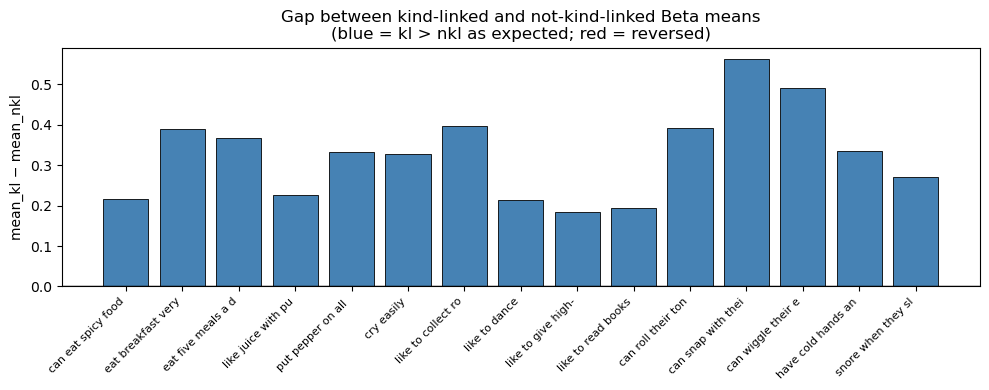

In [91]:
# ── Diagnostic: is mean_kl > mean_nkl per feature? ──────────────────────────
# If the mixture is capturing kind-linking, kl component should have higher
# mean prevalence than nkl. Gap near zero = mixture not doing useful work.

gaps = {}
for feat, params in feature_betas.items():
    mean_kl  = params['alpha_kl']  / (params['alpha_kl']  + params['beta_kl'])
    mean_nkl = params['alpha_nkl'] / (params['alpha_nkl'] + params['beta_nkl'])
    gaps[feat] = mean_kl - mean_nkl

n_positive = sum(g > 0 for g in gaps.values())
print(f"mean_kl > mean_nkl: {n_positive}/{len(gaps)} features\n")
print(f"{'feature':<30}  {'mean_kl':>8}  {'mean_nkl':>8}  {'gap':>8}  {'w_std':>8}")
print("-" * 70)
for j, col in enumerate(TEST_COLS):
    feat = CSV_TO_FEATURE[col]
    p = feature_betas[feat]
    mean_kl  = p['alpha_kl']  / (p['alpha_kl']  + p['beta_kl'])
    mean_nkl = p['alpha_nkl'] / (p['alpha_nkl'] + p['beta_nkl'])
    w_std = float(np.std([r['fitted_both_preds'][j] for r in results]))
    flag = '  ✗' if gaps[feat] <= 0 else ''
    print(f"{feat:<30}  {mean_kl:>8.3f}  {mean_nkl:>8.3f}  {gaps[feat]:>+8.3f}  {w_std:>8.3f}{flag}")

# Bar chart of gaps
fig, ax = plt.subplots(figsize=(10, 4))
feat_list = list(gaps.keys())
gap_vals  = [gaps[f] for f in feat_list]
colors = ['steelblue' if g > 0 else 'tomato' for g in gap_vals]
ax.bar(range(len(feat_list)), gap_vals, color=colors, edgecolor='black', linewidth=0.6)
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(range(len(feat_list)))
ax.set_xticklabels([f[:18] for f in feat_list], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('mean_kl − mean_nkl')
ax.set_title('Gap between kind-linked and not-kind-linked Beta means\n(blue = kl > nkl as expected; red = reversed)')
plt.tight_layout()
plt.show()


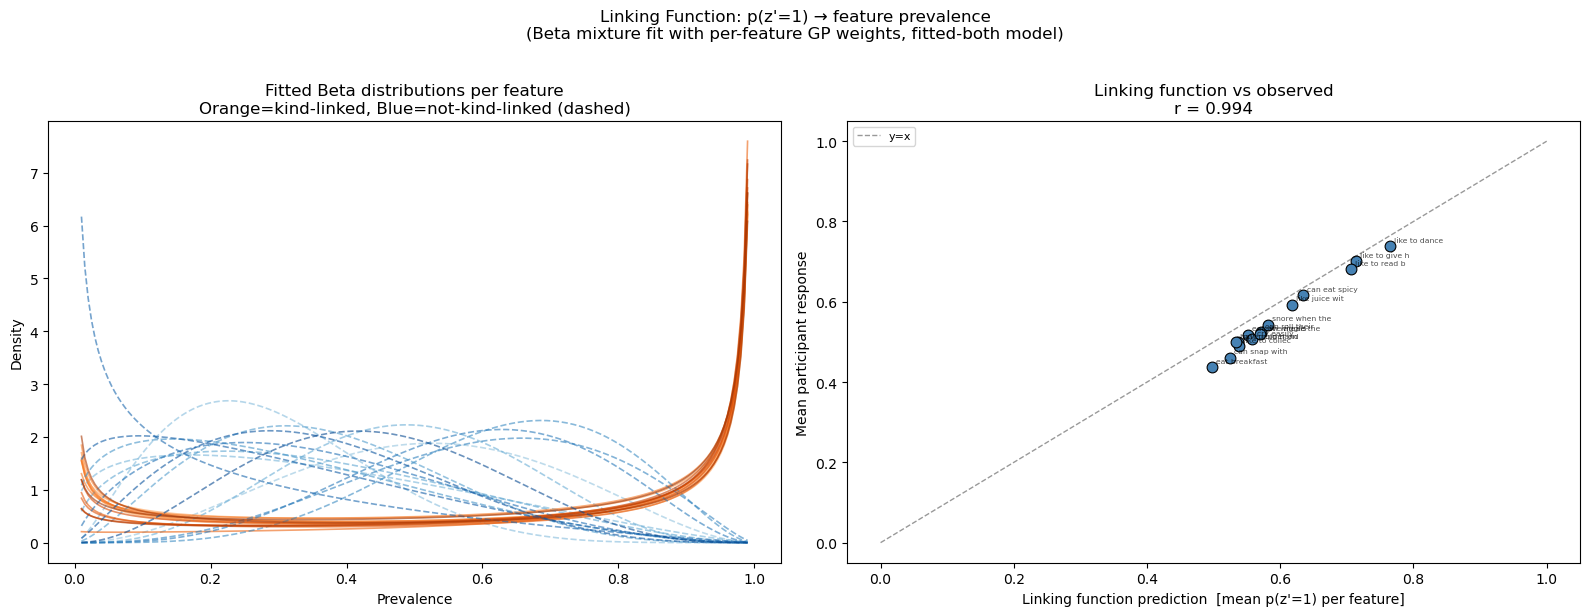

In [92]:
def linking_function(feature_pz1, feature_betas):
    """
    Predict E[prevalence] per feature given per-feature p(z'=1).
    feature_pz1:   dict {feature_name: p(z'_j=1)}  — GP-inferred P(kind-linked) per feature
    feature_betas: dict {feature_name: {alpha_kl, beta_kl, alpha_nkl, beta_nkl}}
    Returns dict: feature_name -> predicted mean prevalence
    """
    preds = {}
    for feat, params in feature_betas.items():
        pz1      = feature_pz1[feat]
        mean_kl  = params['alpha_kl']  / (params['alpha_kl']  + params['beta_kl'])
        mean_nkl = params['alpha_nkl'] / (params['alpha_nkl'] + params['beta_nkl'])
        preds[feat] = pz1 * mean_kl + (1 - pz1) * mean_nkl
    return preds


# Mean p(z'_j=1) across participants for each feature j
mean_pz1 = {
    CSV_TO_FEATURE[col]: float(np.mean([r['fitted_both_preds'][j] for r in results]))
    for j, col in enumerate(TEST_COLS)
}

# ── Visualization: 2-panel overview ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Per-feature Beta distributions (kind-linked=orange, not-kl=blue)
ax = axes[0]
x_vals = np.linspace(0.01, 0.99, 200)
n_feats    = len(feature_betas)
colors_kl  = plt.cm.Oranges(np.linspace(0.4, 0.9, n_feats))
colors_nkl = plt.cm.Blues(np.linspace(0.4, 0.9, n_feats))
for k, (feat, params) in enumerate(feature_betas.items()):
    pdf_kl  = beta_dist.pdf(x_vals, params['alpha_kl'],  params['beta_kl'])
    pdf_nkl = beta_dist.pdf(x_vals, params['alpha_nkl'], params['beta_nkl'])
    ax.plot(x_vals, pdf_kl,  color=colors_kl[k],  alpha=0.6, lw=1.2)
    ax.plot(x_vals, pdf_nkl, color=colors_nkl[k], alpha=0.6, lw=1.2, linestyle='--')
ax.set_xlabel('Prevalence')
ax.set_ylabel('Density')
ax.set_title('Fitted Beta distributions per feature\nOrange=kind-linked, Blue=not-kind-linked (dashed)')

# Panel 2: Linking function prediction vs mean participant response per feature
ax = axes[1]
link_preds = linking_function(mean_pz1, feature_betas)
mean_responses = {CSV_TO_FEATURE[col]: float(np.mean([r['responses'][j] for r in results]))
                  for j, col in enumerate(TEST_COLS)}

feat_list   = list(link_preds.keys())
pred_vals   = [link_preds[f]     for f in feat_list]
actual_vals = [mean_responses[f] for f in feat_list]

ax.scatter(pred_vals, actual_vals, s=60, color='steelblue', edgecolors='black', linewidths=0.8)
for f, p, a in zip(feat_list, pred_vals, actual_vals):
    ax.annotate(f[:14], (p, a), fontsize=5.5, alpha=0.7, xytext=(3, 3), textcoords='offset points')
lo, hi = 0, 1
ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.4, label='y=x')
r_link, _ = pearsonr(pred_vals, actual_vals)
ax.set_xlabel('Linking function prediction  [mean p(z\'=1) per feature]')
ax.set_ylabel('Mean participant response')
ax.set_title(f'Linking function vs observed\nr = {r_link:.3f}')
ax.legend(fontsize=8)

plt.suptitle(
    'Linking Function: p(z\'=1) → feature prevalence\n'
    '(Beta mixture fit with per-feature GP weights, fitted-both model)',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()


In [ ]:
# # ── Leave-one-out cross-validation for the linking function ─────────────────
# # For each held-out participant i:
# #   1. Fit Beta params on all other participants (using their per-feature GP weights)
# #   2. Predict held-out participant's responses using their own GP weights + held-out Beta params
# #   3. Correlate predicted vs actual across 15 features
# # Note: uses 2 restarts per feature fit to keep runtime reasonable.

# def fit_beta_mixture_fast(responses_j, weights):
#     """Same as fit_beta_mixture but with 2 restarts for speed in LOO loop."""
#     eps = 1e-6
#     r   = np.clip(responses_j, eps, 1 - eps)
#     th  = np.array(weights)
#     def neg_ll(params):
#         a1, b1, a2, b2 = params
#         mixture = th * beta_dist.pdf(r, a1, b1) + (1 - th) * beta_dist.pdf(r, a2, b2)
#         return -np.sum(np.log(np.clip(mixture, 1e-300, None)))
#     best = None
#     for init in [(5, 1, 1, 5), (2, 2, 2, 2)]:
#         res = minimize(neg_ll, x0=init, method='L-BFGS-B', bounds=[(0.1, 50)] * 4)
#         if best is None or res.fun < best.fun:
#             best = res
#     a1, b1, a2, b2 = best.x
#     if a1/(a1+b1) >= a2/(a2+b2):
#         return dict(alpha_kl=a1, beta_kl=b1, alpha_nkl=a2, beta_nkl=b2)
#     else:
#         return dict(alpha_kl=a2, beta_kl=b2, alpha_nkl=a1, beta_nkl=b1)


# cv_results = []
# n = len(results)
# for i_out in range(n):
#     if i_out % 20 == 0:
#         print(f"  LOO fold {i_out+1}/{n}...")
#     train = [r for k, r in enumerate(results) if k != i_out]
#     r_out = results[i_out]

#     # Fit Beta params on training participants
#     fb_cv = {}
#     for j, col in enumerate(TEST_COLS):
#         feat  = CSV_TO_FEATURE[col]
#         resp_j = np.array([r['responses'][j]          for r in train])
#         w_j    = np.array([r['fitted_both_preds'][j]   for r in train])
#         fb_cv[feat] = fit_beta_mixture_fast(resp_j, w_j)

#     # Predict held-out participant
#     preds_cv, actual_cv = [], []
#     for j, col in enumerate(TEST_COLS):
#         feat = CSV_TO_FEATURE[col]
#         pz1  = float(r_out['fitted_both_preds'][j])
#         p    = fb_cv[feat]
#         mean_kl  = p['alpha_kl']  / (p['alpha_kl']  + p['beta_kl'])
#         mean_nkl = p['alpha_nkl'] / (p['alpha_nkl'] + p['beta_nkl'])
#         preds_cv.append(pz1 * mean_kl + (1 - pz1) * mean_nkl)
#         actual_cv.append(float(r_out['responses'][j]))

#     r_cv = pearsonr(preds_cv, actual_cv)[0] \
#            if np.std(preds_cv) > 1e-6 and np.std(actual_cv) > 1e-6 else np.nan
#     cv_results.append(dict(condition=r_out['condition'], r_cv=r_cv,
#                            preds=preds_cv, actual=actual_cv))

# print("LOO-CV complete.")

# # ── Summary ───────────────────────────────────────────────────────────────────
# r_insample = pearsonr(
#     [link_preds[f]     for f in feat_list],
#     [mean_responses[f] for f in feat_list]
# )[0]

# # LOO: aggregate predicted/actual across all participants then correlate at feature level
# all_preds_cv   = np.zeros(len(TEST_COLS))
# all_actual_cv  = np.zeros(len(TEST_COLS))
# for res_cv in cv_results:
#     all_preds_cv  += np.array(res_cv['preds'])
#     all_actual_cv += np.array(res_cv['actual'])
# all_preds_cv  /= n
# all_actual_cv /= n
# r_loo_agg = pearsonr(all_preds_cv, all_actual_cv)[0]

# r_loo_per_ppt = [res_cv['r_cv'] for res_cv in cv_results if not np.isnan(res_cv['r_cv'])]

# print(f"\nIn-sample r (feature-level means):  {r_insample:.3f}")
# print(f"LOO-CV r    (feature-level means):  {r_loo_agg:.3f}")
# print(f"LOO-CV r    (per-participant mean):  {np.mean(r_loo_per_ppt):.3f}  "
#       f"median={np.median(r_loo_per_ppt):.3f}  std={np.std(r_loo_per_ppt):.3f}")
# print()
# for cond in ['physical', 'diet', 'personality', 'heterogeneous']:
#     vals = [res_cv['r_cv'] for res_cv in cv_results
#             if res_cv['condition'] == cond and not np.isnan(res_cv['r_cv'])]
#     print(f"  {cond:<16}  mean r={np.mean(vals):.3f}  median={np.median(vals):.3f}  n={len(vals)}")

  LOO fold 1/402...
  LOO fold 21/402...
  LOO fold 41/402...
  LOO fold 61/402...


In [ ]:
# # ── Visualization ─────────────────────────────────────────────────────────────
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # Panel 1: LOO feature-level scatter (mirrors Panel 2 of link-func-viz-03 but held-out)
# ax = axes[0]
# feat_order = [CSV_TO_FEATURE[col] for col in TEST_COLS]
# ax.scatter(all_preds_cv, all_actual_cv, s=60, color='steelblue',
#            edgecolors='black', linewidths=0.8)
# for f, p, a in zip(feat_order, all_preds_cv, all_actual_cv):
#     ax.annotate(f[:14], (p, a), fontsize=5.5, alpha=0.7, xytext=(3, 3),
#                 textcoords='offset points')
# ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='y=x')
# ax.set_xlabel('LOO-CV prediction (mean over participants)')
# ax.set_ylabel('Mean participant response')
# ax.set_title(f'LOO-CV: linking function vs observed\nr = {r_loo_agg:.3f}  (in-sample r = {r_insample:.3f})')
# ax.legend(fontsize=8)

# # Panel 2: Distribution of per-participant LOO correlations by condition
# ax = axes[1]
# cond_colors = {'physical': 'tab:red', 'diet': 'tab:green',
#                'personality': 'tab:blue', 'heterogeneous': 'tab:purple'}
# cond_order  = ['physical', 'diet', 'personality', 'heterogeneous']
# for k, cond in enumerate(cond_order):
#     vals = [res_cv['r_cv'] for res_cv in cv_results
#             if res_cv['condition'] == cond and not np.isnan(res_cv['r_cv'])]
#     ax.scatter([k] * len(vals), vals, alpha=0.35, s=18,
#                color=cond_colors[cond], edgecolors='none')
#     ax.plot([k - 0.3, k + 0.3], [np.median(vals)] * 2,
#             color=cond_colors[cond], lw=2.5, label=f'{cond} (med={np.median(vals):.2f})')
# ax.axhline(0, color='gray', linestyle=':', lw=1)
# ax.set_xticks(range(len(cond_order)))
# ax.set_xticklabels(cond_order, rotation=15)
# ax.set_ylabel('Per-participant LOO-CV r')
# ax.set_title('LOO-CV correlation by condition')
# ax.legend(fontsize=7)

# plt.suptitle('Linking Function: Leave-One-Out Cross-Validation', fontsize=12, y=1.02)
# plt.tight_layout()
# plt.show()

# Scatterplot: model (linking function) vs human prevalence judgments
these scatterplots taking the means of participant prevalence judgments for each feature and comparing to sampled means of model judgments for each feature

In [111]:
cond_colors = {'physical': 'tab:red', 'diet': 'tab:green',
               'personality': 'tab:blue', 'heterogeneous': 'tab:purple'}

model_preds_all  = []
human_resps_all  = []
conditions_all   = []

for r in results:
    cond = r['condition']
    for j, col in enumerate(TEST_COLS):
        feat    = CSV_TO_FEATURE[col]
        pz1     = float(r['fitted_both_preds'][j])
        params  = feature_betas[feat]
        mean_kl  = params['alpha_kl']  / (params['alpha_kl']  + params['beta_kl'])
        mean_nkl = params['alpha_nkl'] / (params['alpha_nkl'] + params['beta_nkl'])
        model_pred = pz1 * mean_kl + (1 - pz1) * mean_nkl
        model_preds_all.append(model_pred)
        human_resps_all.append(float(r['responses'][j]))
        conditions_all.append(cond)

model_preds_all = np.array(model_preds_all)
human_resps_all = np.array(human_resps_all)
conditions_all  = np.array(conditions_all)

# r² overall
r_all, _ = pearsonr(model_preds_all, human_resps_all)
r2_all   = r_all ** 2

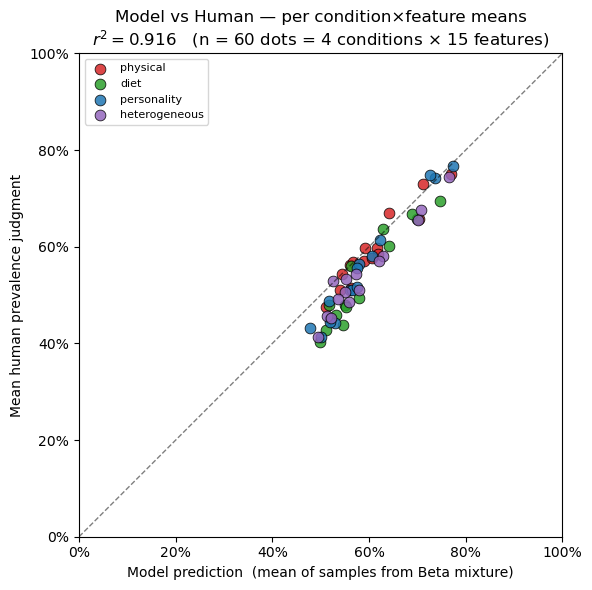

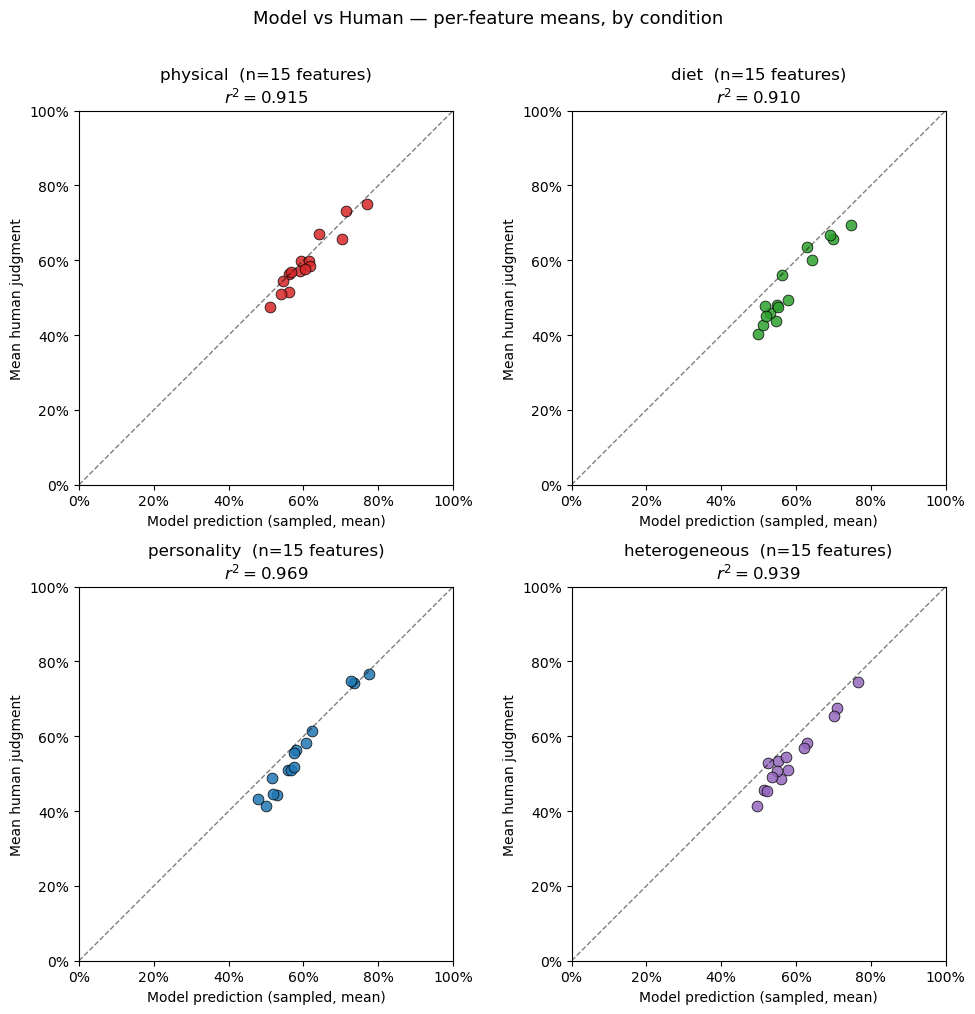

In [112]:
# ── Scatterplot: sampled from linking function vs human prevalence judgments ──
#
# Comparing one sample per participant×feature is too noisy (both axes).
# Instead we aggregate: mean model prediction per condition×feature (averaged
# over N_SAMPLES draws) vs mean human response per condition×feature.
# This matches the study-6 approach (df_prag_feature_means vs df_tidy_feature_means).

N_SAMPLES = 400   # samples per participant×feature; mean over these → stable estimate
rng = np.random.default_rng(42)

# Build arrays: (N_participants × 15,) for mean sampled prediction
# We average N_SAMPLES draws to get a stable per-participant×feature mean
model_preds_sampled = []
for r in results:
    for j, col in enumerate(TEST_COLS):
        feat   = CSV_TO_FEATURE[col]
        pz1    = float(r['fitted_both_preds'][j])
        params = feature_betas[feat]
        # draw N_SAMPLES from the mixture, take mean
        z    = rng.random(N_SAMPLES) < pz1
        samp = np.where(z,
                        rng.beta(params['alpha_kl'],  params['beta_kl'],  N_SAMPLES),
                        rng.beta(params['alpha_nkl'], params['beta_nkl'], N_SAMPLES))
        model_preds_sampled.append(samp.mean())

model_preds_sampled = np.array(model_preds_sampled)

# ── Aggregate to condition × feature means ────────────────────────────────
feat_names   = [CSV_TO_FEATURE[col] for col in TEST_COLS]   # (15,) feature labels

rows = []
for r, mp in zip(results, model_preds_sampled.reshape(len(results), 15)):
    for j, feat in enumerate(feat_names):
        rows.append({'condition': r['condition'], 'feature': feat,
                     'human': r['responses'][j], 'model': mp[j]})

import pandas as pd
df_scatter = pd.DataFrame(rows)
df_feat_means = df_scatter.groupby(['condition', 'feature'])[['human', 'model']].mean().reset_index()

# ── Overall r² ────────────────────────────────────────────────────────────
r_all, _ = pearsonr(df_feat_means['model'], df_feat_means['human'])

# ── Single combined plot ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
for cond in ['physical', 'diet', 'personality', 'heterogeneous']:
    d = df_feat_means[df_feat_means['condition'] == cond]
    ax.scatter(d['model'], d['human'], color=cond_colors[cond],
               s=60, edgecolors='black', linewidths=0.6, alpha=0.85, label=cond)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlim(0, 1);  ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.set_xlabel('Model prediction  (mean of samples from Beta mixture)')
ax.set_ylabel('Mean human prevalence judgment')
ax.set_title(f'Model vs Human — per condition×feature means\n'
             f'$r^2 = {r_all**2:.3f}$   (n = {len(df_feat_means)} dots = 4 conditions × 15 features)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
plt.tight_layout()
plt.show()

# ── 2×2 by condition ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for idx, cond in enumerate(['physical', 'diet', 'personality', 'heterogeneous']):
    ax = axes[idx // 2, idx % 2]
    d  = df_feat_means[df_feat_means['condition'] == cond]
    r_cond, _ = pearsonr(d['model'], d['human'])
    ax.scatter(d['model'], d['human'], color=cond_colors[cond],
               s=60, edgecolors='black', linewidths=0.6, alpha=0.85)
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlim(0, 1);  ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.set_xlabel('Model prediction (sampled, mean)')
    ax.set_ylabel('Mean human judgment')
    ax.set_title(f'{cond}  (n={len(d)} features)\n$r^2 = {r_cond**2:.3f}$')
    ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
plt.suptitle('Model vs Human — per-feature means, by condition', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

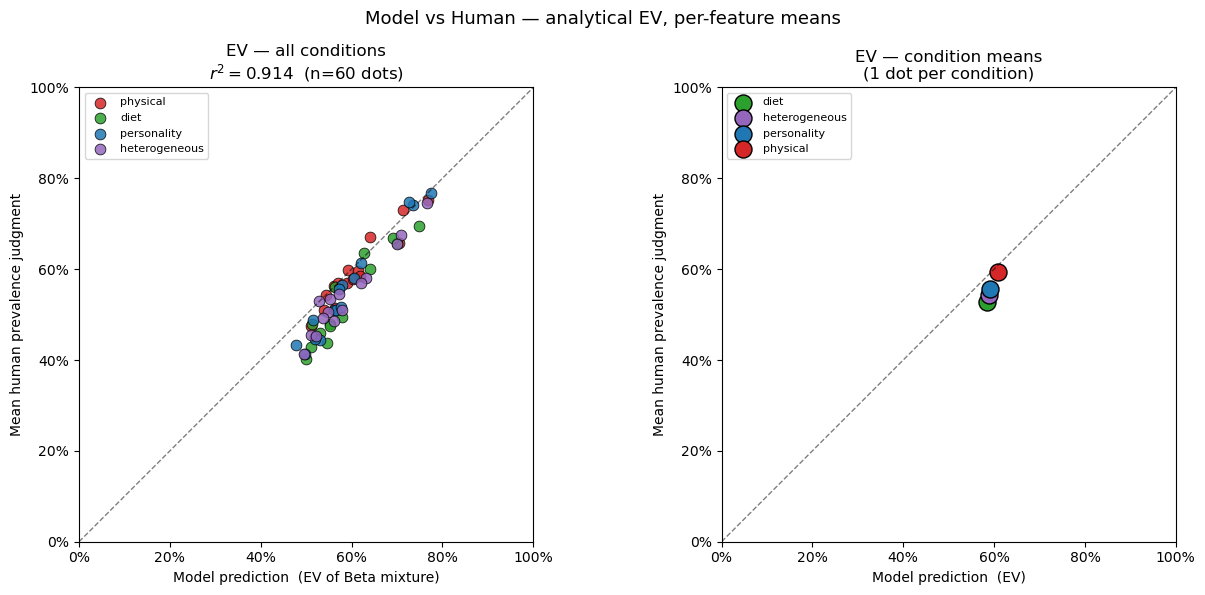

In [101]:
# ── Same plot using analytical EV (no sampling) ───────────────────────────
# model_preds_all and human_resps_all already computed in the EV scatter cell above

rows_ev = []
for r, mp in zip(results, model_preds_all.reshape(len(results), 15)):
    for j, feat in enumerate(feat_names):
        rows_ev.append({'condition': r['condition'], 'feature': feat,
                        'human': r['responses'][j], 'model': mp[j]})

df_feat_means_ev = pd.DataFrame(rows_ev).groupby(['condition', 'feature'])[['human', 'model']].mean().reset_index()
r_ev, _ = pearsonr(df_feat_means_ev['model'], df_feat_means_ev['human'])

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Panel 1: all conditions together
ax = axes[0]
for cond in ['physical', 'diet', 'personality', 'heterogeneous']:
    d = df_feat_means_ev[df_feat_means_ev['condition'] == cond]
    ax.scatter(d['model'], d['human'], color=cond_colors[cond],
               s=60, edgecolors='black', linewidths=0.6, alpha=0.85, label=cond)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlim(0, 1);  ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.set_xlabel('Model prediction  (EV of Beta mixture)')
ax.set_ylabel('Mean human prevalence judgment')
ax.set_title(f'EV — all conditions\n$r^2 = {r_ev**2:.3f}$  (n={len(df_feat_means_ev)} dots)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))

# Panel 2: condition means only (4 dots)
df_cond_means_ev = df_feat_means_ev.groupby('condition')[['human', 'model']].mean().reset_index()
ax = axes[1]
for _, row in df_cond_means_ev.iterrows():
    ax.scatter(row['model'], row['human'], color=cond_colors[row['condition']],
               s=150, edgecolors='black', linewidths=1, label=row['condition'])
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlim(0, 1);  ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.set_xlabel('Model prediction  (EV)')
ax.set_ylabel('Mean human prevalence judgment')
ax.set_title('EV — condition means\n(1 dot per condition)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))

plt.suptitle('Model vs Human — analytical EV, per-feature means', fontsize=13)
plt.tight_layout()
plt.show()

can eat spicy food                mean_kl=0.998  mean_nkl=0.534
eat breakfast very late           mean_kl=0.577  mean_nkl=0.265
eat five meals a day              mean_kl=0.950  mean_nkl=0.432
like juice with pulp              mean_kl=0.998  mean_nkl=0.516
put pepper on all their foods     mean_kl=0.729  mean_nkl=0.451
cry easily                        mean_kl=0.756  mean_nkl=0.470
like to collect rocks             mean_kl=0.743  mean_nkl=0.433
like to dance                     mean_kl=0.793  mean_nkl=0.678
like to give high-fives           mean_kl=0.747  mean_nkl=0.637
like to read books                mean_kl=0.739  mean_nkl=0.620
can roll their tongue             mean_kl=0.782  mean_nkl=0.463
can snap with their toes          mean_kl=0.587  mean_nkl=0.246
can wiggle their ears             mean_kl=0.998  mean_nkl=0.443
have cold hands and feet          mean_kl=0.702  mean_nkl=0.449
snore when they sleep             mean_kl=0.998  mean_nkl=0.498


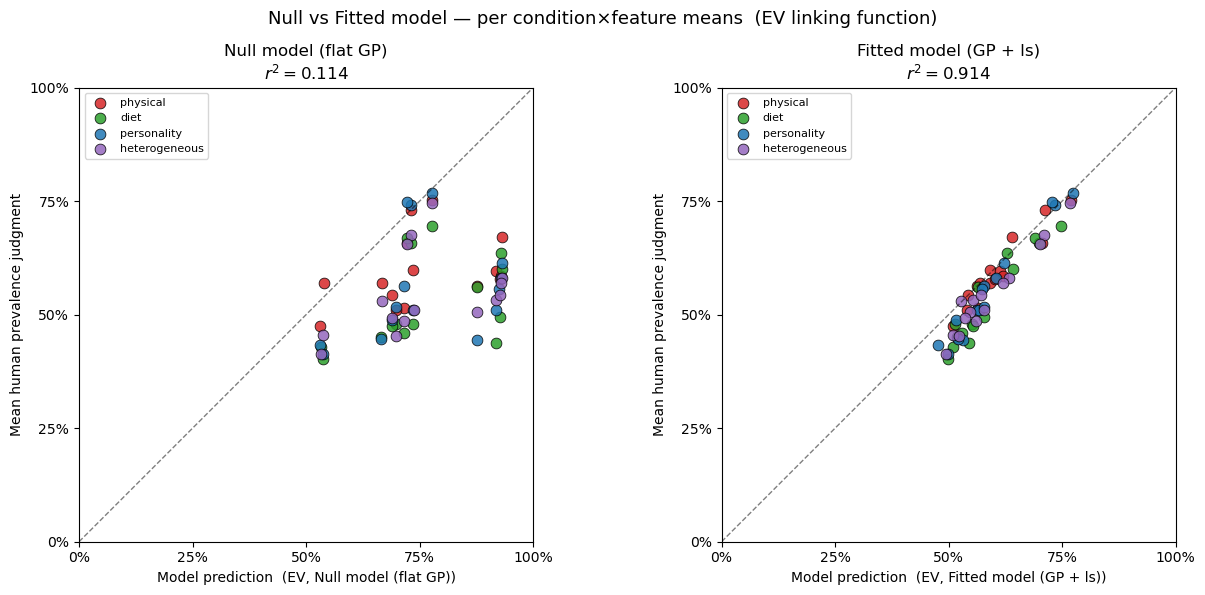

Null model:   r = 0.338,  r² = 0.114
Fitted model: r = 0.956,  r² = 0.914


In [118]:
# ── Null model comparison: same EV scatter using null_preds as weights ────────

# ── Refit betas with null weights ─────────────────────────────────────────
feature_betas_null = {}
for j, col in enumerate(TEST_COLS):
    feat   = CSV_TO_FEATURE[col]
    resp_j = np.array([r['responses'][j]  for r in results])
    w_j    = np.array([r['null_preds'][j] for r in results])
    feature_betas_null[feat] = fit_beta_mixture(resp_j, w_j)
    p = feature_betas_null[feat]
    print(f"{feat:<32}  mean_kl={p['alpha_kl']/(p['alpha_kl']+p['beta_kl']):.3f}  "
          f"mean_nkl={p['alpha_nkl']/(p['alpha_nkl']+p['beta_nkl']):.3f}")

# ── EV predictions using null weights + null betas ────────────────────────
model_preds_null_ev = []
for r in results:
    for j, col in enumerate(TEST_COLS):
        feat    = CSV_TO_FEATURE[col]
        pz1     = float(r['null_preds'][j])
        params  = feature_betas_null[feat]
        mean_kl  = params['alpha_kl']  / (params['alpha_kl']  + params['beta_kl'])
        mean_nkl = params['alpha_nkl'] / (params['alpha_nkl'] + params['beta_nkl'])
        model_preds_null_ev.append(pz1 * mean_kl + (1 - pz1) * mean_nkl)

model_preds_null_ev    = np.array(model_preds_null_ev).reshape(len(results), 15)
model_preds_fitted_mat = model_preds_all.reshape(len(results), 15)

# ── Aggregate to condition × feature means ────────────────────────────────
rows_null = []
for i, r in enumerate(results):
    for j, feat in enumerate(feat_names):
        rows_null.append({'condition': r['condition'], 'feature': feat,
                          'human':        r['responses'][j],
                          'model_null':   model_preds_null_ev[i, j],
                          'model_fitted': model_preds_fitted_mat[i, j]})

df_null = pd.DataFrame(rows_null).groupby(['condition', 'feature'])[
    ['human', 'model_null', 'model_fitted']].mean().reset_index()

r_null,   _ = pearsonr(df_null['model_null'],   df_null['human'])
r_fitted, _ = pearsonr(df_null['model_fitted'], df_null['human'])

# ── Side-by-side: null vs fitted ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, xcol, label, r_val in [
    (axes[0], 'model_null',   'Null model (flat GP)',   r_null),
    (axes[1], 'model_fitted', 'Fitted model (GP + ls)', r_fitted),
]:
    for cond in ['physical', 'diet', 'personality', 'heterogeneous']:
        d = df_null[df_null['condition'] == cond]
        ax.scatter(d[xcol], d['human'], color=cond_colors[cond],
                   s=60, edgecolors='black', linewidths=0.6, alpha=0.85, label=cond)
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlim(0, 1);  ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.set_xlabel(f'Model prediction  (EV, {label})')
    ax.set_ylabel('Mean human prevalence judgment')
    ax.set_title(f'{label}\n$r^2 = {r_val**2:.3f}$')
    ax.legend(fontsize=8)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))

plt.suptitle('Null vs Fitted model — per condition×feature means  (EV linking function)',
             fontsize=13)
plt.tight_layout()
plt.show()

print(f"Null model:   r = {r_null:.3f},  r² = {r_null**2:.3f}")
print(f"Fitted model: r = {r_fitted:.3f},  r² = {r_fitted**2:.3f}")

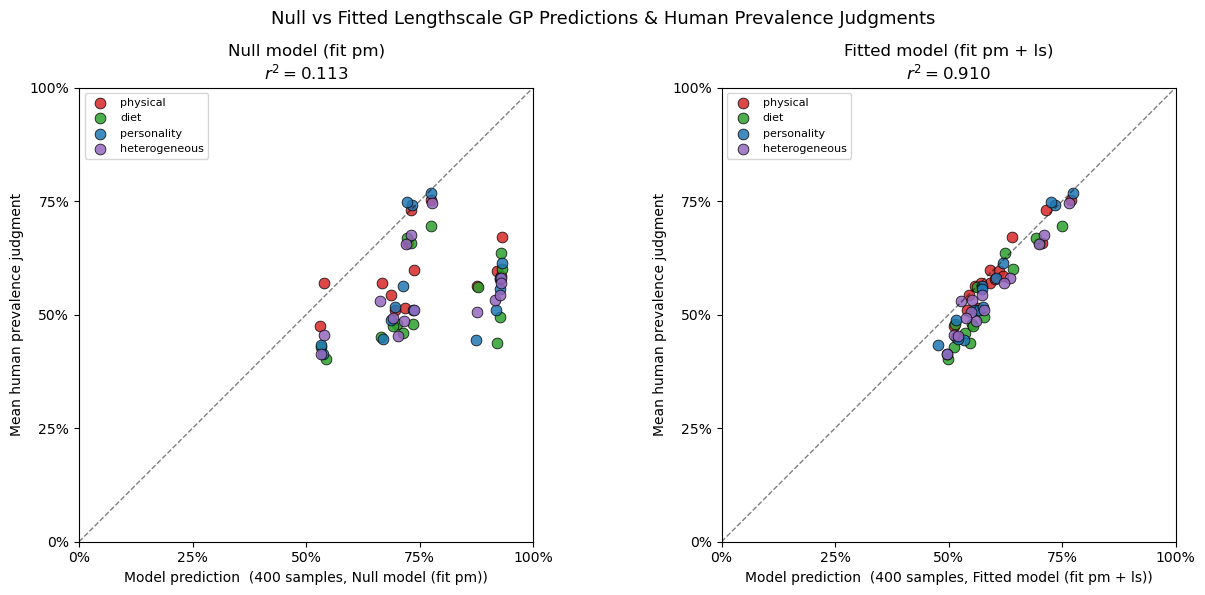

Null model:   r = 0.336,  r² = 0.113
Fitted model: r = 0.954,  r² = 0.910


In [117]:
# ── Same comparison using 500 samples from Beta mixture (null vs fitted) ─────

N_SAMPLES = 400
rng = np.random.default_rng(42)

def sample_linking(results_list, betas, pred_key):
    """Mean of N_SAMPLES draws from Beta mixture per participant×feature."""
    out = np.zeros((len(results_list), 15))
    for i, r in enumerate(results_list):
        for j, col in enumerate(TEST_COLS):
            feat   = CSV_TO_FEATURE[col]
            pz1    = float(r[pred_key][j])
            params = betas[feat]
            z    = rng.random(N_SAMPLES) < pz1
            samp = np.where(z,
                            rng.beta(params['alpha_kl'],  params['beta_kl'],  N_SAMPLES),
                            rng.beta(params['alpha_nkl'], params['beta_nkl'], N_SAMPLES))
            out[i, j] = samp.mean()
    return out

preds_null_samp   = sample_linking(results, feature_betas_null, 'null_preds')
preds_fitted_samp = sample_linking(results, feature_betas,      'fitted_both_preds')

# ── Aggregate to condition × feature means ────────────────────────────────
rows_samp = []
for i, r in enumerate(results):
    for j, feat in enumerate(feat_names):
        rows_samp.append({'condition': r['condition'], 'feature': feat,
                          'human':        r['responses'][j],
                          'model_null':   preds_null_samp[i, j],
                          'model_fitted': preds_fitted_samp[i, j]})

df_samp = pd.DataFrame(rows_samp).groupby(['condition', 'feature'])[
    ['human', 'model_null', 'model_fitted']].mean().reset_index()

r_null_s,   _ = pearsonr(df_samp['model_null'],   df_samp['human'])
r_fitted_s, _ = pearsonr(df_samp['model_fitted'], df_samp['human'])

# ── Side-by-side plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, xcol, label, r_val in [
    (axes[0], 'model_null',   'Null model (fit pm)',   r_null_s),
    (axes[1], 'model_fitted', 'Fitted model (fit pm + ls)', r_fitted_s),
]:
    for cond in ['physical', 'diet', 'personality', 'heterogeneous']:
        d = df_samp[df_samp['condition'] == cond]
        ax.scatter(d[xcol], d['human'], color=cond_colors[cond],
                   s=60, edgecolors='black', linewidths=0.6, alpha=0.85, label=cond)
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlim(0, 1);  ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.set_xlabel(f'Model prediction  (400 samples, {label})')
    ax.set_ylabel('Mean human prevalence judgment')
    ax.set_title(f'{label}\n$r^2 = {r_val**2:.3f}$')
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))

plt.suptitle('Null vs Fitted Lengthscale GP Predictions & Human Prevalence Judgments',
             fontsize=13)
plt.tight_layout()
plt.show()

print(f"Null model:   r = {r_null_s:.3f},  r² = {r_null_s**2:.3f}")
print(f"Fitted model: r = {r_fitted_s:.3f},  r² = {r_fitted_s**2:.3f}")